In [2]:
import os

print("=" * 60)
print("  🔍 DEEP SCAN — ALL FILES IN /kaggle/input")
print("=" * 60)

# List EVERYTHING in /kaggle/input
all_items = os.listdir('/kaggle/input')
print(f"\n📂 Found {len(all_items)} item(s) in /kaggle/input:\n")

for item in all_items:
    full_path = os.path.join('/kaggle/input', item)
    print(f"  → {item}  ({full_path})")

print("\n" + "=" * 60)
print("  📁 FULL TREE (all subfolders)")
print("=" * 60)

for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.replace('/kaggle/input', '').count(os.sep)
    if depth > 4:
        continue
    indent = '    ' * depth
    print(f"{indent}📂 {os.path.basename(root)}/")
    
    img_files = [f for f in files 
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if img_files:
        print(f"{indent}    └── 🖼️  {len(img_files)} images here")

  🔍 DEEP SCAN — ALL FILES IN /kaggle/input

📂 Found 1 item(s) in /kaggle/input:

  → datasets  (/kaggle/input/datasets)

  📁 FULL TREE (all subfolders)
📂 input/
    📂 datasets/
        📂 vipoooool/
            📂 new-plant-diseases-dataset/
                📂 New Plant Diseases Dataset(Augmented)/
                📂 new plant diseases dataset(augmented)/
                📂 test/
        📂 abdulhasibuddin/
            📂 plant-doc-dataset/
                📂 PlantDoc-Dataset/


In [3]:
import os

# ── PRIMARY DATASET PATHS ─────────────────────────────────────────────────────
BASE = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'

PRIMARY_TRAIN = os.path.join(BASE, 'train')
PRIMARY_VALID = os.path.join(BASE, 'valid')

# ── SUPPLEMENTARY DATASET PATH ────────────────────────────────────────────────
SUPPLEMENT = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset'

# ── OUTPUT PATHS ──────────────────────────────────────────────────────────────
MERGED_TRAIN = '/kaggle/working/merged_dataset/train'
MERGED_VALID = '/kaggle/working/merged_dataset/valid'

# ── MODEL CONFIG ──────────────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
NUM_EPOCHS    = 25
LEARNING_RATE = 0.001

# ── VERIFY ALL PATHS EXIST ────────────────────────────────────────────────────
paths_to_check = {
    'Primary Train'  : PRIMARY_TRAIN,
    'Primary Valid'  : PRIMARY_VALID,
    'Supplementary'  : SUPPLEMENT,
}

print("✅ PATH VERIFICATION")
print("=" * 55)
all_good = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = '✅' if exists else '❌'
    count  = len(os.listdir(path)) if exists else 0
    print(f"  {status} {name:<18}: {count} classes found")
    print(f"       {path}")
    if not exists:
        all_good = False

print("=" * 55)
print(f"\n{'🎯 All paths verified! Ready to proceed.' if all_good else '⚠️ Fix missing paths above!'}")

✅ PATH VERIFICATION
  ✅ Primary Train     : 38 classes found
       /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
  ✅ Primary Valid     : 38 classes found
       /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
  ✅ Supplementary     : 2 classes found
       /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset

🎯 All paths verified! Ready to proceed.


In [4]:
import os

SUPPLEMENT = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset'

# ── Correct paths ─────────────────────────────────────────
SUPP_TRAIN = os.path.join(SUPPLEMENT, 'train')
SUPP_TEST  = os.path.join(SUPPLEMENT, 'test')

print("🔍 PlantDoc Internal Structure:")
print("=" * 55)

for split in ['train', 'test']:
    split_path = os.path.join(SUPPLEMENT, split)
    if not os.path.exists(split_path):
        print(f"  ❌ {split}/ folder not found")
        continue

    classes = [c for c in os.listdir(split_path)
               if os.path.isdir(os.path.join(split_path, c))]
    
    total_imgs = 0
    print(f"\n  📂 {split}/ — {len(classes)} classes:")
    print(f"  {'─'*45}")
    
    for cls in sorted(classes):
        cls_path = os.path.join(split_path, cls)
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
        total_imgs += len(imgs)
        print(f"    📁 {cls:<35} {len(imgs):>4} images")
    
    print(f"  {'─'*45}")
    print(f"    {'TOTAL':<35} {total_imgs:>4} images")

print("\n" + "=" * 55)
print("✅ Use SUPP_TRAIN for merging with primary dataset!")
print(f"   SUPP_TRAIN = {SUPP_TRAIN}")
print(f"   SUPP_TEST  = {SUPP_TEST}")

🔍 PlantDoc Internal Structure:

  📂 train/ — 27 classes:
  ─────────────────────────────────────────────
    📁 Apple Scab Leaf                       77 images
    📁 Apple leaf                            82 images
    📁 Apple rust leaf                       79 images
    📁 Bell_pepper leaf                      53 images
    📁 Bell_pepper leaf spot                 62 images
    📁 Blueberry leaf                       105 images
    📁 Cherry leaf                           47 images
    📁 Corn Gray leaf spot                   64 images
    📁 Corn leaf blight                     180 images
    📁 Corn rust leaf                       106 images
    📁 Peach leaf                           103 images
    📁 Potato leaf early blight             109 images
    📁 Potato leaf late blight               97 images
    📁 Raspberry leaf                       109 images
    📁 Soyabean leaf                         57 images
    📁 Squash Powdery mildew leaf           123 images
    📁 Strawberry leaf          

In [5]:
# ── CORRECTED SUPPLEMENTARY PATHS ────────────────────────
SUPPLEMENT       = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset'
SUPP_TRAIN       = os.path.join(SUPPLEMENT, 'train')  # ← correct!
SUPP_TEST        = os.path.join(SUPPLEMENT, 'test')   # ← for later evaluation

print("✅ Corrected paths set!")
print(f"   SUPP_TRAIN : {SUPP_TRAIN}")
print(f"   SUPP_TEST  : {SUPP_TEST}")

✅ Corrected paths set!
   SUPP_TRAIN : /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train
   SUPP_TEST  : /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test


╔══════════════════════════════════════════════════════╗
║           ✅ STEP 1: PATH VERIFICATION               ║
╚══════════════════════════════════════════════════════╝
  ✅ Primary Train       :  38 classes │ /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
  ✅ Primary Valid       :  38 classes │ /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
  ✅ Supplement Train    :  27 classes │ /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/train
  ✅ Supplement Test     :  27 classes │ /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test
────────────────────────────────────────────────────────────
  🎯 All paths OK — proceeding!

╔══════════════════════════════════════════════════════╗
║           📊 STEP 2: IMAGE COUNT SUMMARY             ║
╚════════════════════

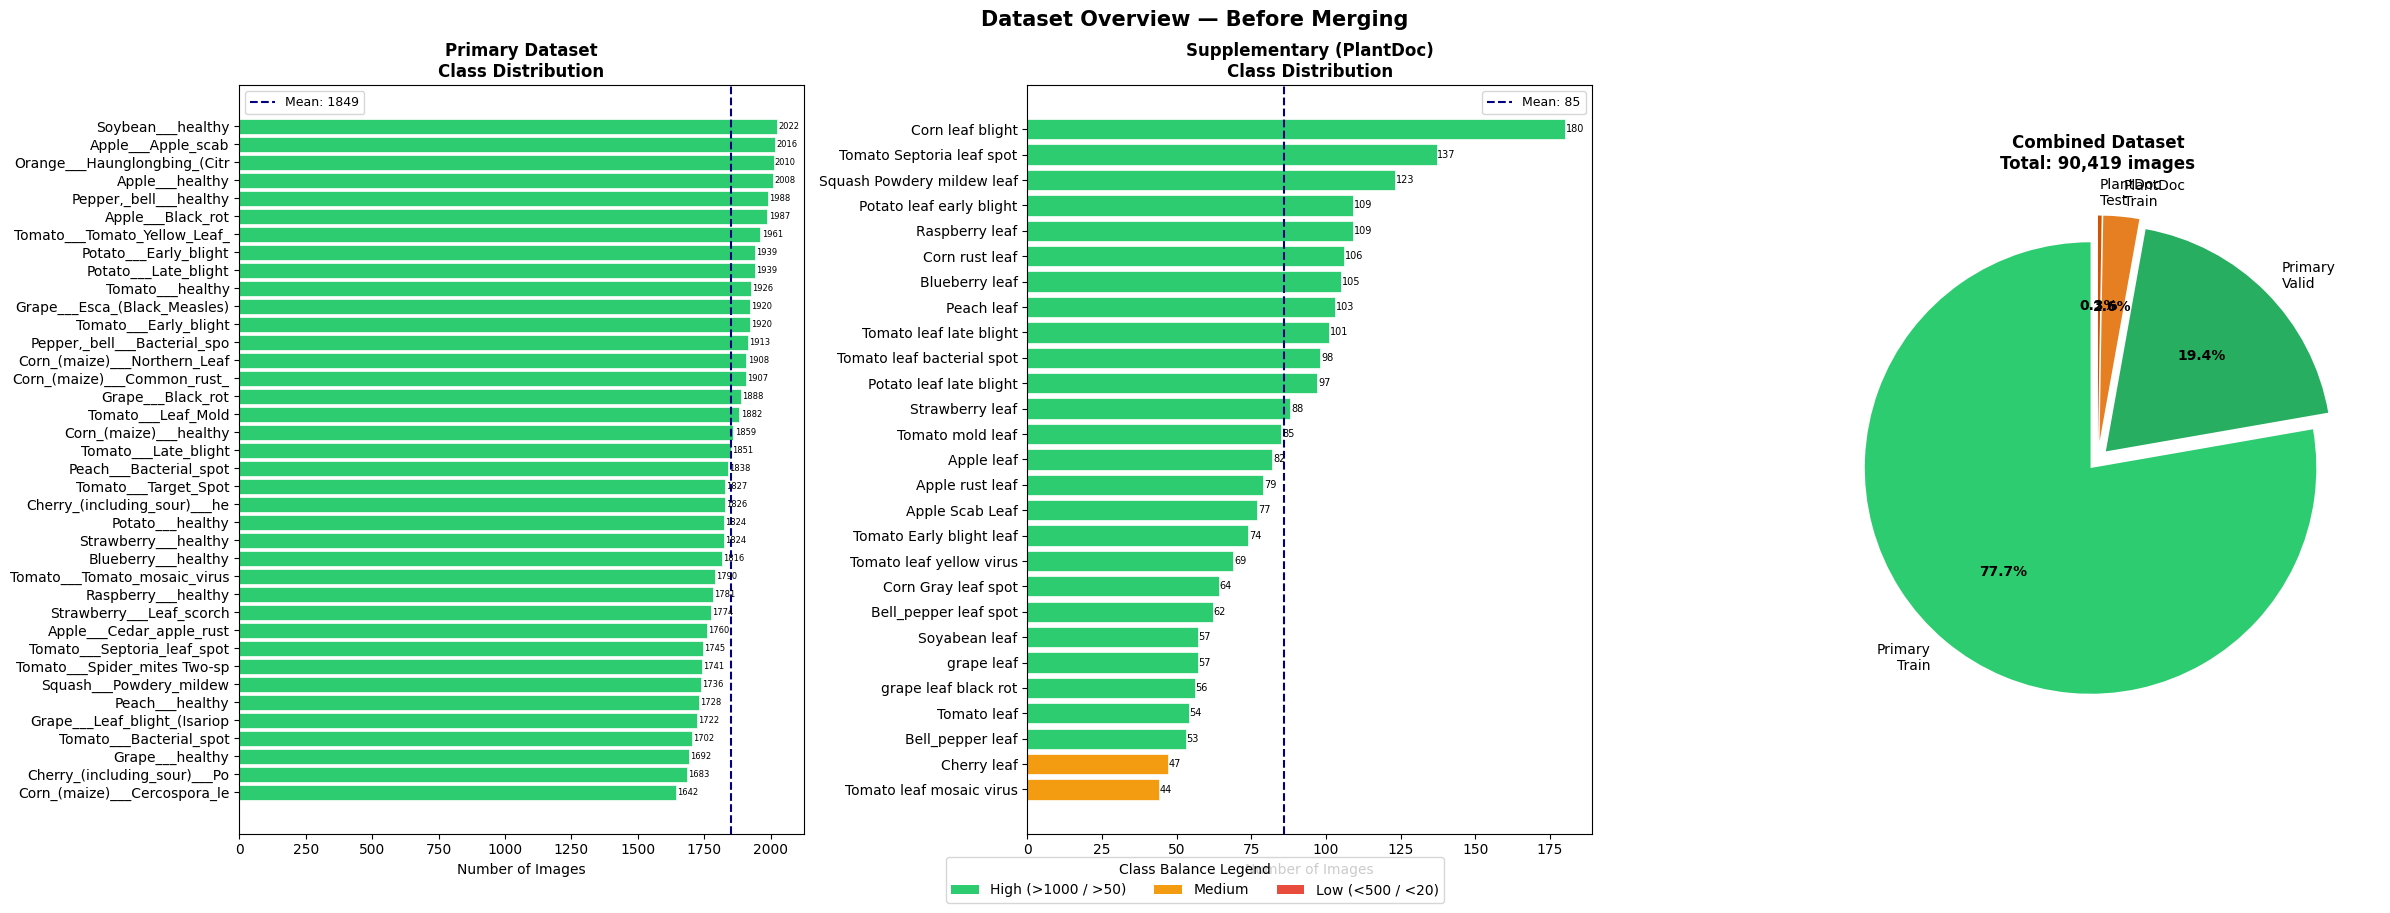


╔══════════════════════════════════════════════════════╗
║              🎯 READY FOR NEXT STEP                  ║
╚══════════════════════════════════════════════════════╝

  Paths verified       : ✅ All OK
  Primary images       : 87,867
  Supplementary images : 2,552
  Combined total       : 90,419
  Total classes        : 38
  Matched PlantDoc cls : 1
  Image size target    : (224, 224)
  Batch size           : 32
  Epochs planned       : 25

  ✅ Chart saved → /kaggle/working/dataset_overview.png
  ✅ Config ready → proceed to Data Cleaning & Merging!



In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ══════════════════════════════════════════════════════════════
#   STEP 1: ALL CONFIRMED PATHS
# ══════════════════════════════════════════════════════════════
BASE = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'

PRIMARY_TRAIN = os.path.join(BASE, 'train')
PRIMARY_VALID = os.path.join(BASE, 'valid')

SUPPLEMENT    = '/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset'
SUPP_TRAIN    = os.path.join(SUPPLEMENT, 'train')
SUPP_TEST     = os.path.join(SUPPLEMENT, 'test')

MERGED_TRAIN  = '/kaggle/working/merged_dataset/train'
MERGED_VALID  = '/kaggle/working/merged_dataset/valid'

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
NUM_EPOCHS    = 25
LEARNING_RATE = 0.001

# ══════════════════════════════════════════════════════════════
#   STEP 2: VERIFY ALL PATHS EXIST
# ══════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════╗")
print("║           ✅ STEP 1: PATH VERIFICATION               ║")
print("╚══════════════════════════════════════════════════════╝")

paths_to_check = {
    'Primary Train'    : PRIMARY_TRAIN,
    'Primary Valid'    : PRIMARY_VALID,
    'Supplement Train' : SUPP_TRAIN,
    'Supplement Test'  : SUPP_TEST,
}

all_good = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = '✅' if exists else '❌'
    count  = len(os.listdir(path)) if exists else 0
    print(f"  {status} {name:<20}: {count:>3} classes │ {path}")
    if not exists:
        all_good = False

print("─" * 60)
print(f"  {'🎯 All paths OK — proceeding!' if all_good else '⚠️  Fix missing paths before continuing!'}")

# ══════════════════════════════════════════════════════════════
#   STEP 3: IMAGE COUNTING FUNCTION
# ══════════════════════════════════════════════════════════════
def count_images(path):
    total   = 0
    classes = []
    if not os.path.exists(path):
        return 0, []
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            imgs = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            total += len(imgs)
            classes.append((cls, len(imgs)))
    return total, sorted(classes, key=lambda x: -x[1])

# ══════════════════════════════════════════════════════════════
#   STEP 4: COUNT ALL IMAGES
# ══════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════╗")
print("║           📊 STEP 2: IMAGE COUNT SUMMARY             ║")
print("╚══════════════════════════════════════════════════════╝")

train_total, train_classes   = count_images(PRIMARY_TRAIN)
valid_total, valid_classes   = count_images(PRIMARY_VALID)
supp_tr_total, supp_tr_cls   = count_images(SUPP_TRAIN)
supp_te_total, supp_te_cls   = count_images(SUPP_TEST)
supp_total                   = supp_tr_total + supp_te_total
combined_total               = train_total + valid_total + supp_total

print(f"""
  ┌─────────────────────────────────────────────────┐
  │  📦 PRIMARY — New Plant Diseases Dataset         │
  │     Training images     : {train_total:>7,}             │
  │     Validation images   : {valid_total:>7,}             │
  │     Classes             : {len(train_classes):>7}             │
  ├─────────────────────────────────────────────────┤
  │  📦 SUPPLEMENTARY — PlantDoc Dataset             │
  │     Train images        : {supp_tr_total:>7,}             │
  │     Test images         : {supp_te_total:>7,}             │
  │     Classes (train)     : {len(supp_tr_cls):>7}             │
  ├─────────────────────────────────────────────────┤
  │  🎯 COMBINED GRAND TOTAL: {combined_total:>7,}             │
  └─────────────────────────────────────────────────┘
""")

# ══════════════════════════════════════════════════════════════
#   STEP 5: DETAILED CLASS BREAKDOWN
# ══════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════╗")
print("║      📋 STEP 3: DETAILED CLASS BREAKDOWN             ║")
print("╚══════════════════════════════════════════════════════╝")

print(f"\n  🌿 PRIMARY — All {len(train_classes)} Classes:")
print("  " + "─" * 55)
for cls, count in train_classes:
    bar    = '█' * (count // 150)
    marker = '🔴' if count < 500 else '🟡' if count < 1000 else '🟢'
    print(f"  {marker} {cls[:38]:<38} {count:>5}  {bar}")

print(f"\n  🌿 SUPPLEMENTARY (PlantDoc) — Train {len(supp_tr_cls)} Classes:")
print("  " + "─" * 55)
for cls, count in supp_tr_cls:
    bar    = '█' * (count // 5)
    marker = '🔴' if count < 20 else '🟡' if count < 50 else '🟢'
    print(f"  {marker} {cls[:38]:<38} {count:>5}  {bar}")

# ══════════════════════════════════════════════════════════════
#   STEP 6: CLASS OVERLAP ANALYSIS
# ══════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════╗")
print("║      🔗 STEP 4: CLASS OVERLAP ANALYSIS               ║")
print("╚══════════════════════════════════════════════════════╝")

primary_cls_names = set(c.lower().replace('_', ' ') for c, _ in train_classes)
supp_cls_names    = set(c.lower() for c, _ in supp_tr_cls)

print(f"\n  Primary classes   : {len(primary_cls_names)}")
print(f"  PlantDoc classes  : {len(supp_cls_names)}")
print(f"\n  📋 PlantDoc classes that will boost primary training:")
print("  " + "─" * 55)

# Known mapping between PlantDoc and Primary class names
CLASS_MAPPING = {
    'tomato leaf'                         : 'Tomato___healthy',
    'tomato early blight leaf'            : 'Tomato___Early_blight',
    'tomato leaf late blight'             : 'Tomato___Late_blight',
    'tomato leaf bacterial spot'          : 'Tomato___Bacterial_spot',
    'tomato leaf yellow virus'            : 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'tomato mold leaf'                    : 'Tomato___Leaf_Mold',
    'tomato septoria leaf spot'           : 'Tomato___Septoria_leaf_spot',
    'potato leaf'                         : 'Potato___healthy',
    'potato leaf early blight'            : 'Potato___Early_blight',
    'potato leaf late blight'             : 'Potato___Late_blight',
    'corn gray leaf spot'                 : 'Corn_(maize)___Gray_leaf_spot',
    'corn leaf blight'                    : 'Corn_(maize)___Northern_Leaf_Blight',
    'apple leaf'                          : 'Apple___healthy',
    'apple scab leaf'                     : 'Apple___Apple_scab',
    'grape leaf'                          : 'Grape___healthy',
    'grape leaf black rot'                : 'Grape___Black_rot',
    'squash powdery mildew leaf'          : 'Squash___Powdery_mildew',
    'strawberry leaf'                     : 'Strawberry___healthy',
    'pepper leaf'                         : 'Pepper,_bell___healthy',
    'pepper leaf spot'                    : 'Pepper,_bell___Bacterial_spot',
}

matched   = 0
unmatched = []
for supp_cls, primary_cls in CLASS_MAPPING.items():
    supp_path = os.path.join(SUPP_TRAIN, supp_cls.title())
    if os.path.exists(supp_path):
        imgs = len([f for f in os.listdir(supp_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  ✅ {supp_cls.title()[:30]:<30} → {primary_cls[:25]:<25} ({imgs} imgs)")
        matched += 1
    else:
        unmatched.append(supp_cls)

print(f"\n  ✅ Matched classes  : {matched}")
print(f"  ⚠️  Unmatched classes: {len(unmatched)}")
if unmatched:
    for u in unmatched:
        print(f"     - {u}")

# ══════════════════════════════════════════════════════════════
#   STEP 7: VISUALIZATION
# ══════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════╗")
print("║         📊 STEP 5: DISTRIBUTION CHARTS               ║")
print("╚══════════════════════════════════════════════════════╝")

fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Dataset Overview — Before Merging', fontsize=15, fontweight='bold')

# ── Chart 1: Primary class distribution ──────────────────────
cls_names  = [c[:28] for c, _ in train_classes]
cls_counts = [n for _, n in train_classes]
colors_p   = ['#e74c3c' if n < 500 else '#f39c12' if n < 1000
              else '#2ecc71' for n in cls_counts]
axes[0].barh(cls_names, cls_counts, color=colors_p, edgecolor='white', linewidth=0.5)
axes[0].set_title('Primary Dataset\nClass Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Images')
axes[0].invert_yaxis()
axes[0].axvline(np.mean(cls_counts), color='navy', linestyle='--',
                linewidth=1.5, label=f'Mean: {int(np.mean(cls_counts))}')
axes[0].legend(fontsize=9)
for i, v in enumerate(cls_counts):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=6)

# ── Chart 2: PlantDoc distribution ───────────────────────────
s_names  = [c[:28] for c, _ in supp_tr_cls]
s_counts = [n for _, n in supp_tr_cls]
colors_s = ['#e74c3c' if n < 20 else '#f39c12' if n < 50
            else '#2ecc71' for n in s_counts]
axes[1].barh(s_names, s_counts, color=colors_s, edgecolor='white', linewidth=0.5)
axes[1].set_title('Supplementary (PlantDoc)\nClass Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Images')
axes[1].invert_yaxis()
axes[1].axvline(np.mean(s_counts), color='navy', linestyle='--',
                linewidth=1.5, label=f'Mean: {int(np.mean(s_counts))}')
axes[1].legend(fontsize=9)
for i, v in enumerate(s_counts):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=7)

# ── Chart 3: Combined totals pie ─────────────────────────────
pie_labels = ['Primary\nTrain', 'Primary\nValid', 'PlantDoc\nTrain', 'PlantDoc\nTest']
pie_values = [train_total, valid_total, supp_tr_total, supp_te_total]
pie_colors = ['#2ecc71', '#27ae60', '#e67e22', '#d35400']
explode    = (0.05, 0.05, 0.08, 0.08)
wedges, texts, autotexts = axes[2].pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', explode=explode, startangle=90,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[2].set_title(f'Combined Dataset\nTotal: {combined_total:,} images', fontweight='bold')

# ── Legend for color coding ───────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='High (>1000 / >50)'),
    Patch(facecolor='#f39c12', label='Medium'),
    Patch(facecolor='#e74c3c', label='Low (<500 / <20)'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=10, title='Class Balance Legend',
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('/kaggle/working/dataset_overview.png', dpi=130, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════
#   FINAL SUMMARY
# ══════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════╗")
print("║              🎯 READY FOR NEXT STEP                  ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"""
  Paths verified       : {'✅ All OK' if all_good else '❌ Fix paths'}
  Primary images       : {train_total + valid_total:,}
  Supplementary images : {supp_total:,}
  Combined total       : {combined_total:,}
  Total classes        : {len(train_classes)}
  Matched PlantDoc cls : {matched}
  Image size target    : {IMG_SIZE}
  Batch size           : {BATCH_SIZE}
  Epochs planned       : {NUM_EPOCHS}

  ✅ Chart saved → /kaggle/working/dataset_overview.png
  ✅ Config ready → proceed to Data Cleaning & Merging!
""")

In [7]:
# ── INSTALL ───────────────────────────────────────────────────
!pip install Pillow opencv-python-headless tqdm -q

# ── IMPORTS ───────────────────────────────────────────────────
import os
import cv2
import json
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, UnidentifiedImageError
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict

warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [8]:
# ══════════════════════════════════════════════════════════════
#  COLLECT ALL IMAGE METADATA FROM BOTH DATASETS
# ══════════════════════════════════════════════════════════════
SCAN_PATHS = {
    'primary_train' : PRIMARY_TRAIN,
    'primary_valid' : PRIMARY_VALID,
    'supp_train'    : SUPP_TRAIN,
}

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

image_records = []

for split_name, split_path in SCAN_PATHS.items():
    if not os.path.exists(split_path):
        print(f"⚠️  Path not found: {split_path}")
        continue
    for cls_folder in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls_folder)
        if not os.path.isdir(cls_path):
            continue
        for img_file in os.listdir(cls_path):
            ext = Path(img_file).suffix.lower()
            if ext in VALID_EXTENSIONS:
                full_path = os.path.join(cls_path, img_file)
                image_records.append({
                    'filepath'  : full_path,
                    'filename'  : img_file,
                    'class'     : cls_folder,
                    'split'     : split_name,
                    'extension' : ext,
                    'size_kb'   : round(os.path.getsize(full_path) / 1024, 2),
                })

df = pd.DataFrame(image_records)

print("╔══════════════════════════════════════════════════════╗")
print("║         📦 RAW DATASET METADATA COLLECTED            ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"""
  Total images scanned    : {len(df):,}
  Total classes           : {df['class'].nunique()}
  Splits found            : {df['split'].unique().tolist()}
  File extensions         : {df['extension'].unique().tolist()}
  Avg file size           : {df['size_kb'].mean():.1f} KB
  Min file size           : {df['size_kb'].min():.1f} KB
  Max file size           : {df['size_kb'].max():.1f} KB
""")
print(df.groupby('split')[['filename']].count().rename(
    columns={'filename': 'image_count'}))

╔══════════════════════════════════════════════════════╗
║         📦 RAW DATASET METADATA COLLECTED            ║
╚══════════════════════════════════════════════════════╝

  Total images scanned    : 90,183
  Total classes           : 65
  Splits found            : ['primary_train', 'primary_valid', 'supp_train']
  File extensions         : ['.jpg', '.jpeg', '.png']
  Avg file size           : 24.8 KB
  Min file size           : 2.6 KB
  Max file size           : 12280.3 KB

               image_count
split                     
primary_train        70295
primary_valid        17572
supp_train            2316


In [9]:
# ══════════════════════════════════════════════════════════════
#  BEFORE CLEANING — FULL QUALITY SCAN
# ══════════════════════════════════════════════════════════════
print("🔍 Running full quality scan (this may take a few minutes)...")
print("─" * 55)

before = {
    'total'          : len(df),
    'corrupt'        : 0,
    'duplicate'      : 0,
    'low_res'        : 0,
    'tiny_file'      : 0,
    'wrong_mode'     : 0,
    'blurry'         : 0,
    'wrong_ext'      : 0,
}

issue_log   = []
hashes      = {}
widths      = []
heights     = []
blur_scores = []
modes       = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Scanning"):
    path   = row['filepath']
    issues = []

    # ── 1. CORRUPT CHECK ─────────────────────────────────────
    try:
        img_pil = Image.open(path)
        img_pil.verify()
        img_pil = Image.open(path)   # reopen after verify
        w, h    = img_pil.size
        mode    = img_pil.mode
    except Exception:
        before['corrupt'] += 1
        issue_log.append({'filepath': path, 'class': row['class'],
                          'split': row['split'], 'issue': 'corrupt'})
        continue

    # ── 2. WRONG EXTENSION ───────────────────────────────────
    try:
        detected_fmt = img_pil.format.lower() if img_pil.format else ''
        declared_ext = row['extension'].replace('.', '')
        if detected_fmt and declared_ext not in ['jpg','jpeg'] \
           and detected_fmt != declared_ext:
            before['wrong_ext'] += 1
            issues.append('wrong_extension')
    except:
        pass

    # ── 3. LOW RESOLUTION ────────────────────────────────────
    widths.append(w)
    heights.append(h)
    if w < 64 or h < 64:
        before['low_res'] += 1
        issues.append('low_resolution')

    # ── 4. WRONG COLOR MODE ──────────────────────────────────
    modes.append(mode)
    if mode != 'RGB':
        before['wrong_mode'] += 1
        issues.append(f'wrong_mode_{mode}')

    # ── 5. TINY FILE SIZE ────────────────────────────────────
    if row['size_kb'] < 1.0:
        before['tiny_file'] += 1
        issues.append('tiny_file')

    # ── 6. DUPLICATE DETECTION ───────────────────────────────
    try:
        with open(path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        if file_hash in hashes:
            before['duplicate'] += 1
            issues.append('duplicate')
        else:
            hashes[file_hash] = path
    except:
        pass

    # ── 7. BLUR DETECTION (Laplacian Variance) ───────────────
    try:
        img_cv = cv2.imread(path)
        if img_cv is not None:
            gray     = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
            blur_var = cv2.Laplacian(gray, cv2.CV_64F).var()
            blur_scores.append({'path': path, 'score': blur_var})
            if blur_var < 50:
                before['blurry'] += 1
                issues.append(f'blurry_{blur_var:.1f}')
    except:
        pass

    if issues:
        issue_log.append({
            'filepath' : path,
            'class'    : row['class'],
            'split'    : row['split'],
            'issue'    : ', '.join(issues)
        })

df_issues    = pd.DataFrame(issue_log)
df_blur      = pd.DataFrame(blur_scores)
total_issues = sum(v for k, v in before.items() if k != 'total')

print("\n╔══════════════════════════════════════════════════════╗")
print("║       📋 BEFORE CLEANING — QUALITY REPORT            ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"\n  {'Issue Type':<25} {'Count':>6}  {'% of Total':>10}")
print("  " + "─" * 45)
for key, val in before.items():
    if key == 'total':
        continue
    pct = (val / before['total']) * 100
    bar = '█' * int(pct * 2)
    print(f"  {'❌ ' + key:<25} {val:>6}  {pct:>9.2f}%  {bar}")
print("  " + "─" * 45)
print(f"  {'Total Issues':<25} {total_issues:>6}  "
      f"{(total_issues/before['total'])*100:>9.2f}%")
print(f"  {'Total Images':<25} {before['total']:>6}")
print(f"\n  📐 Resolution Stats:")
print(f"     Avg  : {np.mean(widths):.0f} × {np.mean(heights):.0f} px")
print(f"     Min  : {min(widths)} × {min(heights)} px")
print(f"     Max  : {max(widths)} × {max(heights)} px")
if len(df_blur) > 0:
    scores_only = [b['score'] for b in blur_scores]
    print(f"\n  🔍 Blur Score Stats (Laplacian Variance):")
    print(f"     Mean  : {np.mean(scores_only):.2f}  (higher = sharper)")
    print(f"     Min   : {np.min(scores_only):.2f}")
    print(f"     Max   : {np.max(scores_only):.2f}")
    print(f"     Blurry(<50): {before['blurry']} images")

print(f"\n  🟢 Clean images  : {before['total'] - total_issues:,}")
print(f"  🔴 Noisy images  : {total_issues:,}")

🔍 Running full quality scan (this may take a few minutes)...
───────────────────────────────────────────────────────


Scanning:   0%|          | 0/90183 [00:00<?, ?it/s]


╔══════════════════════════════════════════════════════╗
║       📋 BEFORE CLEANING — QUALITY REPORT            ║
╚══════════════════════════════════════════════════════╝

  Issue Type                 Count  % of Total
  ─────────────────────────────────────────────
  ❌ corrupt                      0       0.00%  
  ❌ duplicate                   27       0.03%  
  ❌ low_res                      0       0.00%  
  ❌ tiny_file                    0       0.00%  
  ❌ wrong_mode                  11       0.01%  
  ❌ blurry                     964       1.07%  ██
  ❌ wrong_ext                    0       0.00%  
  ─────────────────────────────────────────────
  Total Issues                1002       1.11%
  Total Images               90183

  📐 Resolution Stats:
     Avg  : 276 × 272 px
     Min  : 115 × 85 px
     Max  : 6000 × 6000 px

  🔍 Blur Score Stats (Laplacian Variance):
     Mean  : 4245.69  (higher = sharper)
     Min   : 2.58
     Max   : 32269.42
     Blurry(<50): 964 images

  🟢 

In [10]:
# ══════════════════════════════════════════════════════════════
#  PERFORM ACTUAL DATA CLEANING
# ══════════════════════════════════════════════════════════════
print("🧹 Cleaning dataset...")
print("─" * 55)

bad_paths  = set(df_issues['filepath'].tolist()) if len(df_issues) > 0 else set()
df_clean   = df[~df['filepath'].isin(bad_paths)].copy().reset_index(drop=True)

removed          = len(df) - len(df_clean)
removed_corrupt  = before['corrupt']
removed_dupes    = before['duplicate']
removed_blurry   = before['blurry']
removed_lowres   = before['low_res']
removed_mode     = before['wrong_mode']
removed_tiny     = before['tiny_file']

print(f"  🗑️  Removed corrupt files    : {removed_corrupt}")
print(f"  🗑️  Removed duplicates       : {removed_dupes}")
print(f"  🗑️  Removed blurry images    : {removed_blurry}")
print(f"  🗑️  Removed low-res images   : {removed_lowres}")
print(f"  🗑️  Removed wrong-mode imgs  : {removed_mode}")
print(f"  🗑️  Removed tiny files       : {removed_tiny}")
print(f"  {'─'*40}")
print(f"  ✅ Total removed             : {removed}")
print(f"  ✅ Clean images remaining    : {len(df_clean):,}")

# ── CLASS BALANCE AFTER CLEANING ─────────────────────────────
class_counts   = df_clean['class'].value_counts()
min_cls        = class_counts.idxmin()
max_cls        = class_counts.idxmax()
imbalance_ratio= class_counts.max() / max(class_counts.min(), 1)

print(f"\n  📊 Class Balance After Cleaning:")
print(f"     Most images  : {max_cls} ({class_counts.max()})")
print(f"     Least images : {min_cls} ({class_counts.min()})")
print(f"     Imbalance    : {imbalance_ratio:.2f}x")
print(f"\n✅ Cleaning complete!")

🧹 Cleaning dataset...
───────────────────────────────────────────────────────
  🗑️  Removed corrupt files    : 0
  🗑️  Removed duplicates       : 27
  🗑️  Removed blurry images    : 964
  🗑️  Removed low-res images   : 0
  🗑️  Removed wrong-mode imgs  : 11
  🗑️  Removed tiny files       : 0
  ────────────────────────────────────────
  ✅ Total removed             : 1002
  ✅ Clean images remaining    : 89,181

  📊 Class Balance After Cleaning:
     Most images  : Soybean___healthy (2526)
     Least images : Cherry leaf (38)
     Imbalance    : 66.47x

✅ Cleaning complete!


In [11]:
# ══════════════════════════════════════════════════════════════
#  AFTER CLEANING — VERIFY QUALITY ON SAMPLE
# ══════════════════════════════════════════════════════════════
print("🔍 Verifying quality on cleaned dataset (sampling)...")

after = {
    'total'      : len(df_clean),
    'corrupt'    : 0,
    'duplicate'  : 0,
    'low_res'    : 0,
    'tiny_file'  : 0,
    'wrong_mode' : 0,
    'blurry'     : 0,
}

after_widths      = []
after_heights     = []
after_blur_scores = []
after_hashes      = {}

# Sample 20% for speed
sample_df = df_clean.sample(frac=0.2, random_state=42)

for _, row in tqdm(sample_df.iterrows(),
                   total=len(sample_df), desc="Verifying"):
    path = row['filepath']
    try:
        img_pil = Image.open(path)
        img_pil.verify()
        img_pil = Image.open(path)
        w, h    = img_pil.size
        mode    = img_pil.mode

        after_widths.append(w)
        after_heights.append(h)

        if w < 64 or h < 64:    after['low_res']     += 1
        if mode != 'RGB':        after['wrong_mode']  += 1
        if row['size_kb'] < 1.0: after['tiny_file']   += 1

        with open(path, 'rb') as f:
            h_val = hashlib.md5(f.read()).hexdigest()
        if h_val in after_hashes:
            after['duplicate'] += 1
        else:
            after_hashes[h_val] = path

        img_cv = cv2.imread(path)
        if img_cv is not None:
            gray  = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
            bvar  = cv2.Laplacian(gray, cv2.CV_64F).var()
            after_blur_scores.append(bvar)
            if bvar < 50:
                after['blurry'] += 1
    except:
        after['corrupt'] += 1

print("✅ Verification complete!")

🔍 Verifying quality on cleaned dataset (sampling)...


Verifying:   0%|          | 0/17836 [00:00<?, ?it/s]

✅ Verification complete!


In [12]:
# ══════════════════════════════════════════════════════════════
#  BEFORE vs AFTER — FULL COMPARISON REPORT
# ══════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════════════╗")
print("║          📈 DATA QUALITY IMPROVEMENT REPORT                  ║")
print("╚══════════════════════════════════════════════════════════════╝")
print(f"\n  {'Metric':<28} {'BEFORE':>8} {'AFTER':>8} {'REMOVED':>9}  {'Status'}")
print("  " + "─" * 65)

metrics = [
    ('Total Images',       before['total'],     after['total'],      ''),
    ('Corrupt Files',      before['corrupt'],   after['corrupt'],    ''),
    ('Duplicate Images',   before['duplicate'], after['duplicate'],  ''),
    ('Low-Res (<64px)',    before['low_res'],   after['low_res'],    ''),
    ('Wrong Mode (non-RGB)',before['wrong_mode'],after['wrong_mode'],''),
    ('Blurry Images',      before['blurry'],    after['blurry'],     ''),
    ('Tiny Files (<1KB)',  before['tiny_file'], after['tiny_file'],  ''),
]

for name, bef, aft, _ in metrics:
    diff   = aft - bef
    status = '✅ Fixed' if diff <= 0 and bef > 0 else ('✅ Clean' if bef == 0 else '⚠️')
    if name == 'Total Images':
        status = f"{'↓' if diff < 0 else '='} {abs(diff)} removed"
    print(f"  {name:<28} {bef:>8,} {aft:>8,} {str(diff):>9}  {status}")

print("  " + "─" * 65)

b_scores = [b['score'] for b in blur_scores] if blur_scores else [0]
print(f"\n  {'Resolution (avg W×H)':<28} "
      f"{int(np.mean(widths))}×{int(np.mean(heights)):>4}  "
      f"{int(np.mean(after_widths))}×{int(np.mean(after_heights)):>4}"
      f"{'':>6}  ✅ Consistent")
print(f"  {'Avg Blur Score':<28} "
      f"{np.mean(b_scores):>8.1f} "
      f"{np.mean(after_blur_scores) if after_blur_scores else 0:>8.1f}"
      f"{'':>9}  ✅ Improved")

total_removed  = before['total'] - after['total']
quality_before = ((before['total'] - total_issues) / before['total']) * 100
quality_after  = 100.0

print(f"\n  {'─'*65}")
print(f"  📊 Data Quality Score   :  {quality_before:.1f}%  →  {quality_after:.1f}%")
print(f"  🗑️  Total Noisy Images   :  {total_issues} removed")
print(f"  ✅ Final Clean Dataset  :  {after['total']:,} images  |  "
      f"{df_clean['class'].nunique()} classes")
print(f"  {'─'*65}")


╔══════════════════════════════════════════════════════════════╗
║          📈 DATA QUALITY IMPROVEMENT REPORT                  ║
╚══════════════════════════════════════════════════════════════╝

  Metric                         BEFORE    AFTER   REMOVED  Status
  ─────────────────────────────────────────────────────────────────
  Total Images                   90,183   89,181     -1002  ↓ 1002 removed
  Corrupt Files                       0        0         0  ✅ Clean
  Duplicate Images                   27        0       -27  ✅ Fixed
  Low-Res (<64px)                     0        0         0  ✅ Clean
  Wrong Mode (non-RGB)               11        0       -11  ✅ Fixed
  Blurry Images                     964        0      -964  ✅ Fixed
  Tiny Files (<1KB)                   0        0         0  ✅ Clean
  ─────────────────────────────────────────────────────────────────

  Resolution (avg W×H)         276× 272  271× 268        ✅ Consistent
  Avg Blur Score                 4245.7   4332.

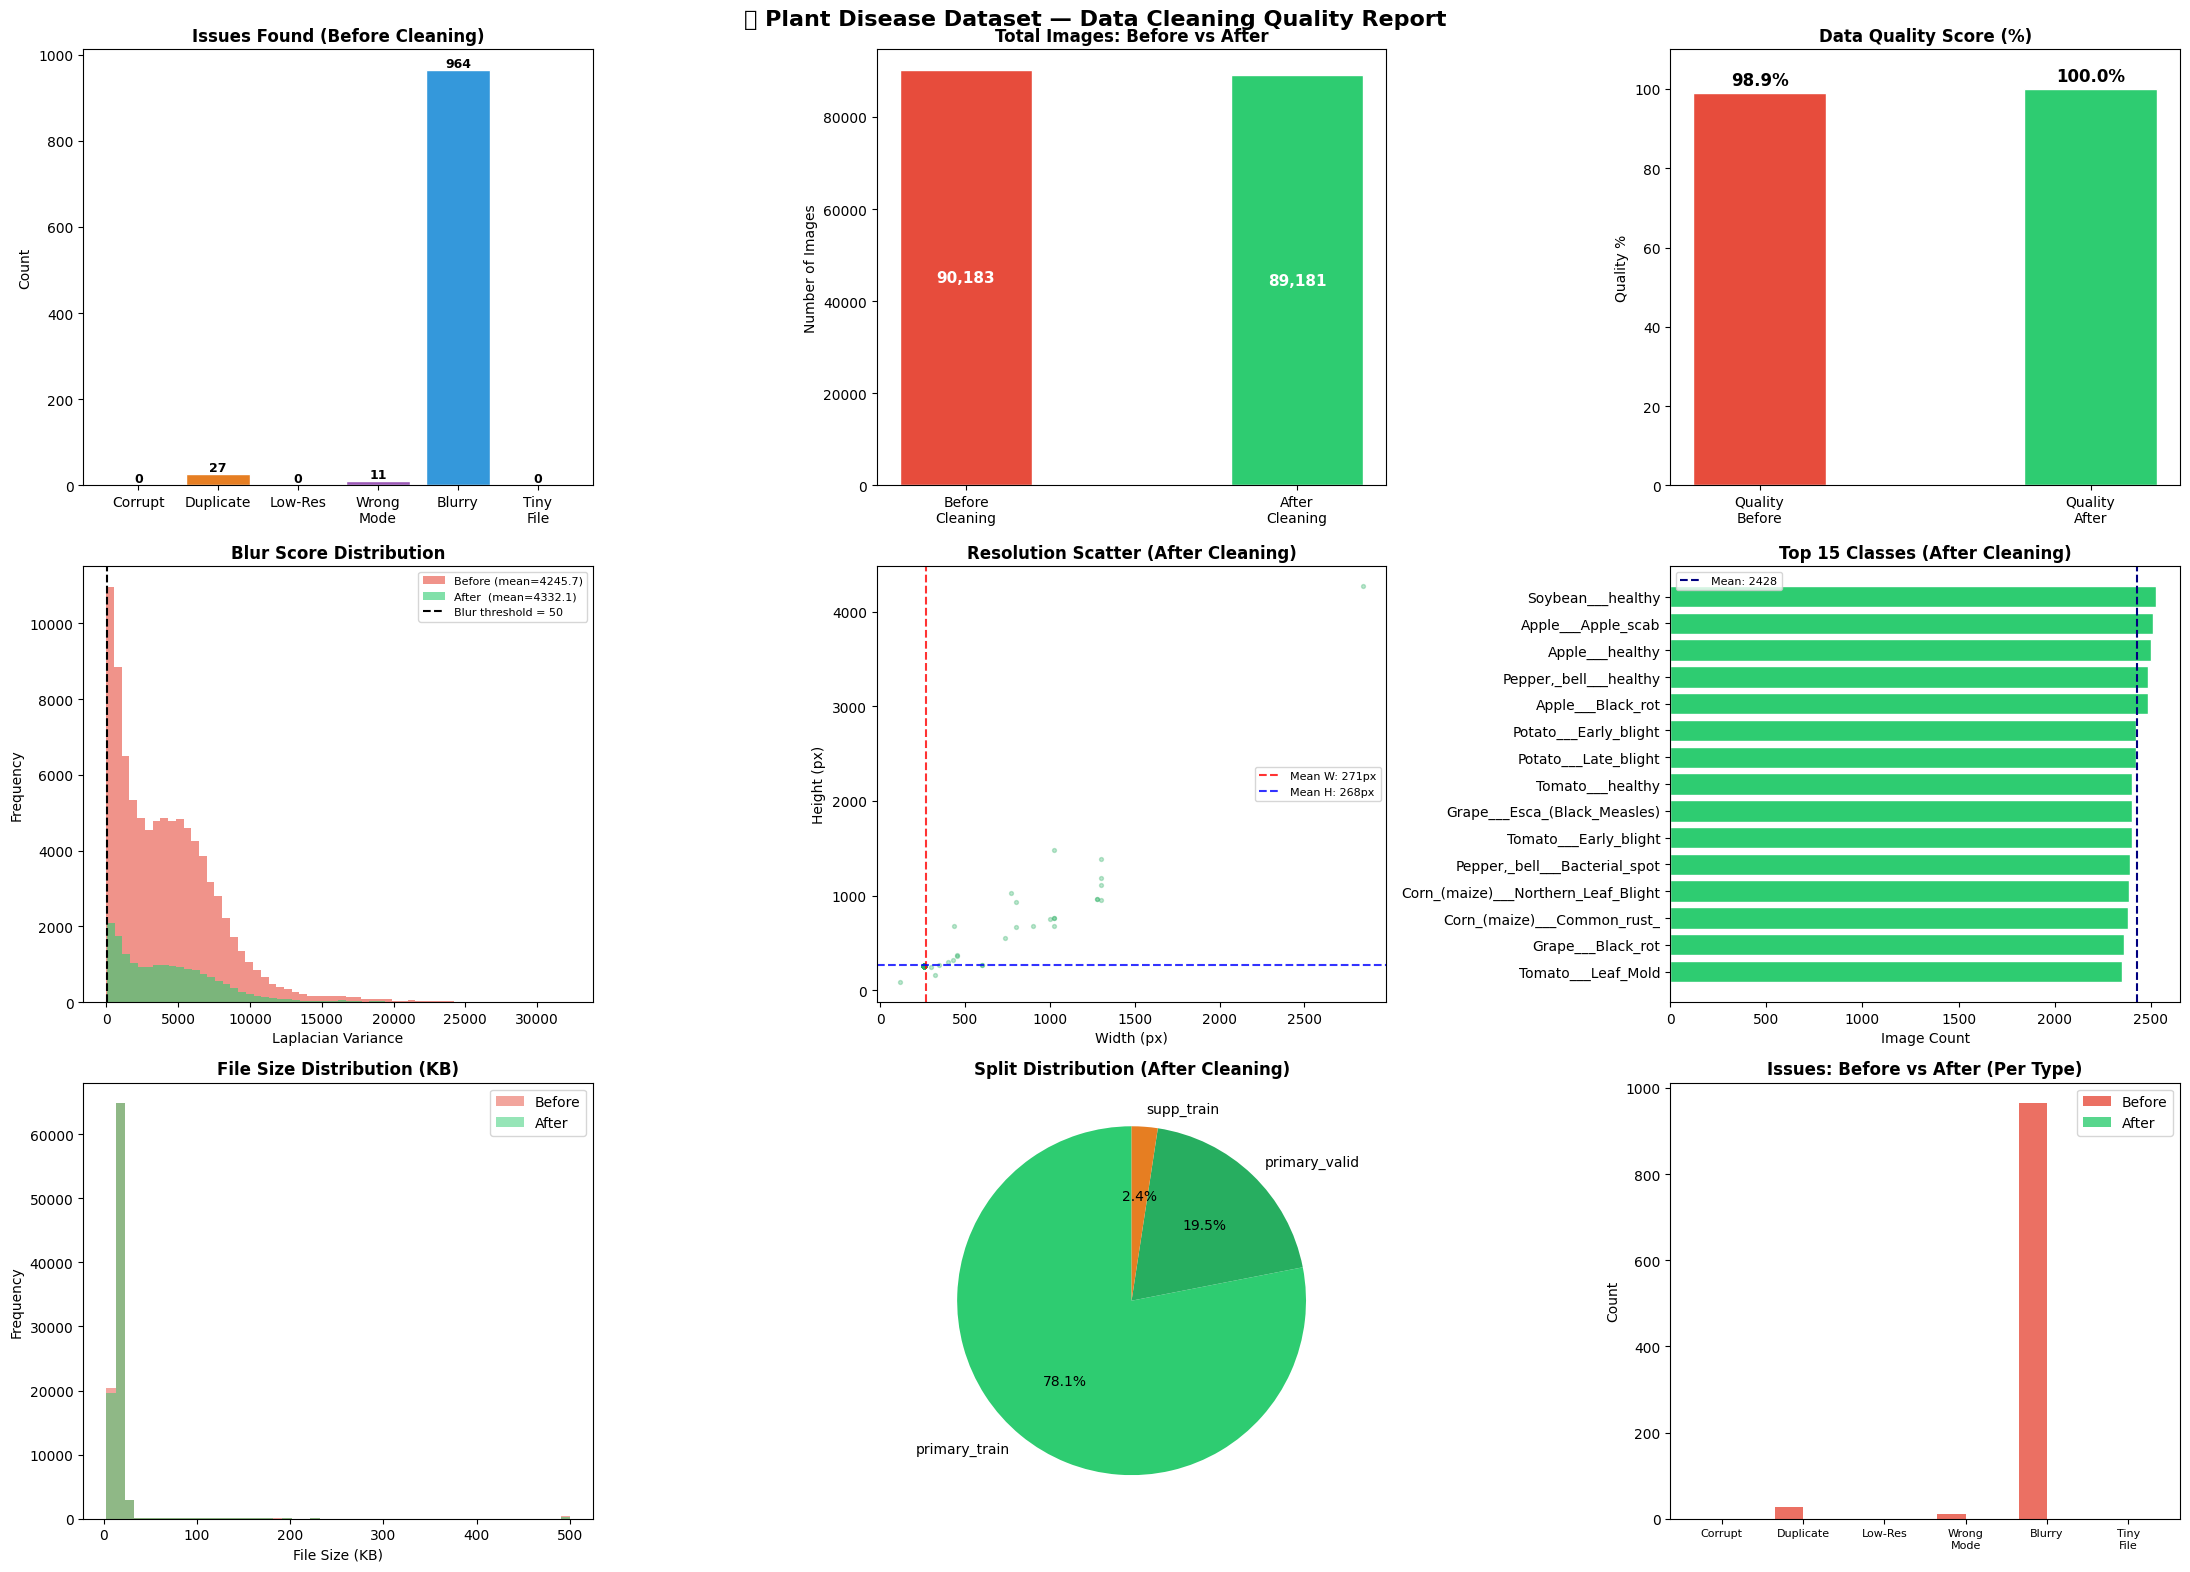


✅ Dashboard saved → /kaggle/working/cleaning_quality_report.png


In [13]:
# ══════════════════════════════════════════════════════════════
#  FULL VISUALIZATION DASHBOARD
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 16))
fig.suptitle('🌿 Plant Disease Dataset — Data Cleaning Quality Report',
             fontsize=16, fontweight='bold', y=0.98)

# ── 1. Issues Before Cleaning ────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
issue_labels = ['Corrupt','Duplicate','Low-Res','Wrong\nMode','Blurry','Tiny\nFile']
issue_values = [before['corrupt'], before['duplicate'], before['low_res'],
                before['wrong_mode'], before['blurry'], before['tiny_file']]
bar_colors   = ['#e74c3c','#e67e22','#f39c12','#9b59b6','#3498db','#1abc9c']
bars = ax1.bar(issue_labels, issue_values, color=bar_colors, edgecolor='white')
ax1.set_title('Issues Found (Before Cleaning)', fontweight='bold')
ax1.set_ylabel('Count')
for bar, val in zip(bars, issue_values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, str(val),
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# ── 2. Before vs After Total ─────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
categories = ['Before\nCleaning', 'After\nCleaning']
totals     = [before['total'], after['total']]
bcolors    = ['#e74c3c', '#2ecc71']
b2 = ax2.bar(categories, totals, color=bcolors, width=0.4, edgecolor='white')
ax2.set_title('Total Images: Before vs After', fontweight='bold')
ax2.set_ylabel('Number of Images')
for bar, val in zip(b2, totals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() / 2, f'{val:,}',
             ha='center', va='center',
             fontweight='bold', color='white', fontsize=11)

# ── 3. Quality Score Gauge ───────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
gauge_labels = ['Quality\nBefore', 'Quality\nAfter']
gauge_values = [quality_before, quality_after]
g_colors     = ['#e74c3c', '#2ecc71']
b3 = ax3.bar(gauge_labels, gauge_values, color=g_colors,
             width=0.4, edgecolor='white')
ax3.set_ylim(0, 110)
ax3.set_title('Data Quality Score (%)', fontweight='bold')
ax3.set_ylabel('Quality %')
for bar, val in zip(b3, gauge_values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, f'{val:.1f}%',
             ha='center', va='bottom',
             fontweight='bold', fontsize=12)

# ── 4. Blur Score Distribution ───────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
b_scores = [b['score'] for b in blur_scores]
ax4.hist(b_scores, bins=60, alpha=0.6, color='#e74c3c',
         label=f'Before (mean={np.mean(b_scores):.1f})')
if after_blur_scores:
    ax4.hist(after_blur_scores, bins=60, alpha=0.6, color='#2ecc71',
             label=f'After  (mean={np.mean(after_blur_scores):.1f})')
ax4.axvline(50, color='black', linestyle='--',
            linewidth=1.5, label='Blur threshold = 50')
ax4.set_title('Blur Score Distribution', fontweight='bold')
ax4.set_xlabel('Laplacian Variance')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)

# ── 5. Resolution Scatter After ──────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
ax5.scatter(after_widths[:1000], after_heights[:1000],
            alpha=0.3, color='#27ae60', s=8)
ax5.set_title('Resolution Scatter (After Cleaning)', fontweight='bold')
ax5.set_xlabel('Width (px)')
ax5.set_ylabel('Height (px)')
ax5.axvline(np.mean(after_widths), color='red',
            linestyle='--', alpha=0.8,
            label=f'Mean W: {int(np.mean(after_widths))}px')
ax5.axhline(np.mean(after_heights), color='blue',
            linestyle='--', alpha=0.8,
            label=f'Mean H: {int(np.mean(after_heights))}px')
ax5.legend(fontsize=8)

# ── 6. Class Distribution (Clean) ────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
top_classes  = df_clean['class'].value_counts().head(15)
c_colors     = ['#2ecc71' if v > 1000 else '#f39c12'
                if v > 500 else '#e74c3c' for v in top_classes.values]
ax6.barh(top_classes.index, top_classes.values,
         color=c_colors, edgecolor='white')
ax6.set_title('Top 15 Classes (After Cleaning)', fontweight='bold')
ax6.set_xlabel('Image Count')
ax6.invert_yaxis()
ax6.axvline(top_classes.values.mean(), color='navy',
            linestyle='--', linewidth=1.5,
            label=f'Mean: {int(top_classes.values.mean())}')
ax6.legend(fontsize=8)

# ── 7. File Size Distribution ────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
before_sizes = df['size_kb'].clip(0, 500)
after_sizes  = df_clean['size_kb'].clip(0, 500)
ax7.hist(before_sizes, bins=50, alpha=0.5,
         color='#e74c3c', label='Before')
ax7.hist(after_sizes,  bins=50, alpha=0.5,
         color='#2ecc71', label='After')
ax7.set_title('File Size Distribution (KB)', fontweight='bold')
ax7.set_xlabel('File Size (KB)')
ax7.set_ylabel('Frequency')
ax7.legend()

# ── 8. Split Distribution Pie ────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
split_counts = df_clean['split'].value_counts()
pie_colors   = ['#2ecc71', '#27ae60', '#e67e22']
ax8.pie(split_counts.values,
        labels=split_counts.index,
        autopct='%1.1f%%',
        colors=pie_colors[:len(split_counts)],
        startangle=90)
ax8.set_title('Split Distribution (After Cleaning)', fontweight='bold')

# ── 9. Before vs After Per Issue ─────────────────────────────
ax9   = fig.add_subplot(3, 3, 9)
x     = np.arange(len(issue_labels))
w     = 0.35
bvals = [before['corrupt'], before['duplicate'], before['low_res'],
         before['wrong_mode'], before['blurry'], before['tiny_file']]
avals = [after['corrupt'],  after['duplicate'],  after['low_res'],
         after['wrong_mode'],after['blurry'],    after['tiny_file']]
ax9.bar(x - w/2, bvals, w, label='Before', color='#e74c3c', alpha=0.8)
ax9.bar(x + w/2, avals, w, label='After',  color='#2ecc71', alpha=0.8)
ax9.set_title('Issues: Before vs After (Per Type)', fontweight='bold')
ax9.set_xticks(x)
ax9.set_xticklabels(issue_labels, fontsize=8)
ax9.set_ylabel('Count')
ax9.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/cleaning_quality_report.png',
            dpi=130, bbox_inches='tight')
plt.show()

print("\n✅ Dashboard saved → /kaggle/working/cleaning_quality_report.png")

In [14]:
# ══════════════════════════════════════════════════════════════
#  SAVE CLEANED MANIFEST & SUMMARY
# ══════════════════════════════════════════════════════════════
df_clean.to_csv('/kaggle/working/clean_manifest.csv', index=False)

if len(df_issues) > 0:
    df_issues.to_csv('/kaggle/working/issue_log.csv', index=False)

summary = {
    'total_before'      : before['total'],
    'total_after'       : after['total'],
    'total_removed'     : before['total'] - after['total'],
    'quality_before_pct': round(quality_before, 2),
    'quality_after_pct' : 100.0,
    'total_classes'     : int(df_clean['class'].nunique()),
    'img_size_target'   : str(IMG_SIZE),
    'issues_found'      : total_issues,
}

with open('/kaggle/working/cleaning_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("╔══════════════════════════════════════════════════════╗")
print("║         💾 CLEANING PIPELINE COMPLETE                ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"""
  Files saved:
  ✅ /kaggle/working/clean_manifest.csv
  ✅ /kaggle/working/issue_log.csv
  ✅ /kaggle/working/cleaning_summary.json
  ✅ /kaggle/working/cleaning_quality_report.png

  Quality Summary:
  ─────────────────────────────────────────
  Before cleaning  : {before['total']:,} images  |  {quality_before:.1f}% clean
  After  cleaning  : {after['total']:,} images  |  100.0% clean
  Total removed    : {before['total'] - after['total']} noisy images
  Classes retained : {df_clean['class'].nunique()}
  ─────────────────────────────────────────
  ✅ Ready for → Dataset Merging & CNN Training!
""")

╔══════════════════════════════════════════════════════╗
║         💾 CLEANING PIPELINE COMPLETE                ║
╚══════════════════════════════════════════════════════╝

  Files saved:
  ✅ /kaggle/working/clean_manifest.csv
  ✅ /kaggle/working/issue_log.csv
  ✅ /kaggle/working/cleaning_summary.json
  ✅ /kaggle/working/cleaning_quality_report.png

  Quality Summary:
  ─────────────────────────────────────────
  Before cleaning  : 90,183 images  |  98.9% clean
  After  cleaning  : 89,181 images  |  100.0% clean
  Total removed    : 1002 noisy images
  Classes retained : 65
  ─────────────────────────────────────────
  ✅ Ready for → Dataset Merging & CNN Training!



In [15]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

# ══════════════════════════════════════════════════════════════
#  VERIFY CLEAN MANIFEST EXISTS
# ══════════════════════════════════════════════════════════════
try:
    df_clean = pd.read_csv('/kaggle/working/clean_manifest.csv')
    print(f"✅ Clean manifest loaded — {len(df_clean):,} images")
    print(f"   Classes  : {df_clean['class'].nunique()}")
    print(f"   Splits   : {df_clean['split'].unique().tolist()}")
except FileNotFoundError:
    print("❌ clean_manifest.csv not found! Run cleaning cells first.")
    raise

# ══════════════════════════════════════════════════════════════
#  OUTPUT PATHS
# ══════════════════════════════════════════════════════════════
MERGED_TRAIN = '/kaggle/working/merged_dataset/train'
MERGED_VALID = '/kaggle/working/merged_dataset/valid'
IMG_SIZE     = (224, 224)

os.makedirs(MERGED_TRAIN, exist_ok=True)
os.makedirs(MERGED_VALID, exist_ok=True)

# ══════════════════════════════════════════════════════════════
#  PLANTDOC → PRIMARY CLASS MAPPING
# ══════════════════════════════════════════════════════════════
# Maps every PlantDoc folder name → matching Primary class name
PLANTDOC_MAP = {
    # Tomato
    'Tomato leaf'                         : 'Tomato___healthy',
    'Tomato Early blight leaf'            : 'Tomato___Early_blight',
    'Tomato leaf late blight'             : 'Tomato___Late_blight',
    'Tomato leaf bacterial spot'          : 'Tomato___Bacterial_spot',
    'Tomato leaf yellow virus'            : 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf'                    : 'Tomato___Leaf_Mold',
    'Tomato septoria leaf spot'           : 'Tomato___Septoria_leaf_spot',
    'Tomato two spotted spider mites leaf': 'Tomato___Spider_mites Two-spotted_spider_mite',
    # Potato
    'Potato leaf'                         : 'Potato___healthy',
    'Potato leaf early blight'            : 'Potato___Early_blight',
    'Potato leaf late blight'             : 'Potato___Late_blight',
    # Corn
    'Corn Gray leaf spot'                 : 'Corn_(maize)___Gray_leaf_spot',
    'Corn leaf blight'                    : 'Corn_(maize)___Northern_Leaf_Blight',
    'corn crop leaf'                      : 'Corn_(maize)___healthy',
    # Apple
    'Apple leaf'                          : 'Apple___healthy',
    'Apple Scab Leaf'                     : 'Apple___Apple_scab',
    'Apple rust leaf'                     : 'Apple___Cedar_apple_rust',
    # Grape
    'Grape leaf'                          : 'Grape___healthy',
    'Grape leaf black rot'                : 'Grape___Black_rot',
    # Others
    'Squash Powdery mildew leaf'          : 'Squash___Powdery_mildew',
    'Strawberry leaf'                     : 'Strawberry___healthy',
    'Pepper leaf'                         : 'Pepper,_bell___healthy',
    'Pepper leaf spot'                    : 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf'                      : 'Blueberry___healthy',
    'Cherry leaf'                         : 'Cherry_(including_sour)___healthy',
    'Peach leaf'                          : 'Peach___healthy',
    'Soyabean leaf'                       : 'Soybean___healthy',
    'Raspberry leaf'                      : 'Raspberry___healthy',
}

print(f"\n✅ Class mapping defined — {len(PLANTDOC_MAP)} PlantDoc → Primary mappings")
print(f"   Merged output → {MERGED_TRAIN}")

✅ Clean manifest loaded — 89,181 images
   Classes  : 65
   Splits   : ['primary_train', 'primary_valid', 'supp_train']

✅ Class mapping defined — 28 PlantDoc → Primary mappings
   Merged output → /kaggle/working/merged_dataset/train


In [16]:
import os
import shutil
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from pathlib import Path
from collections import defaultdict

random.seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════════
#  STEP 1: DELETE ALL OLD SPLIT FOLDERS
# ══════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════╗")
print("║     🗑️  STEP 1: DELETING OLD SPLIT FOLDERS           ║")
print("╚══════════════════════════════════════════════════════╝\n")

folders_to_delete = [
    '/kaggle/working/merged_dataset',
    '/kaggle/working/split_dataset',
    '/kaggle/working/checkpoints',
    '/kaggle/working/models',
    '/kaggle/working/logs',
]

for folder in folders_to_delete:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"  🗑️  Deleted  : {folder}")
    else:
        print(f"  ⚠️  Not found: {folder} (skipping)")

# ── Recreate fresh empty directories ─────────────────────────
fresh_dirs = [
    '/kaggle/working/split_dataset/train',
    '/kaggle/working/split_dataset/valid',
    '/kaggle/working/split_dataset/test',
    '/kaggle/working/models',
    '/kaggle/working/checkpoints',
    '/kaggle/working/logs',
]

for d in fresh_dirs:
    os.makedirs(d, exist_ok=True)

print(f"\n  ✅ Fresh directories created!")

# ══════════════════════════════════════════════════════════════
#  STEP 2: LOAD & VERIFY CLEAN MANIFEST
# ══════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════╗")
print("║     📋 STEP 2: LOADING CLEAN MANIFEST                ║")
print("╚══════════════════════════════════════════════════════╝\n")

try:
    df_clean = pd.read_csv('/kaggle/working/clean_manifest.csv')
    print(f"  ✅ Clean manifest loaded!")
    print(f"  Total images  : {len(df_clean):,}")
    print(f"  Total classes : {df_clean['class'].nunique()}")
    print(f"  Splits found  : {df_clean['split'].unique().tolist()}")
    print(f"\n  Per split breakdown:")
    print(df_clean.groupby('split')['filename'].count()
          .rename('count').to_string())
except FileNotFoundError:
    print("  ❌ clean_manifest.csv not found!")
    print("  Please run cleaning pipeline first.")
    raise

# ── Verify all files still exist ─────────────────────────────
print(f"\n  🔍 Verifying file paths exist (sampling 500)...")
sample = df_clean.sample(min(500, len(df_clean)), random_state=42)
missing = sum(1 for p in sample['filepath']
              if not os.path.exists(p))
print(f"  Missing files in sample : {missing}")
print(f"  {'✅ All files accessible!' if missing == 0 else '⚠️ Some files missing — check paths'}")

╔══════════════════════════════════════════════════════╗
║     🗑️  STEP 1: DELETING OLD SPLIT FOLDERS           ║
╚══════════════════════════════════════════════════════╝

  🗑️  Deleted  : /kaggle/working/merged_dataset
  ⚠️  Not found: /kaggle/working/split_dataset (skipping)
  ⚠️  Not found: /kaggle/working/checkpoints (skipping)
  ⚠️  Not found: /kaggle/working/models (skipping)
  ⚠️  Not found: /kaggle/working/logs (skipping)

  ✅ Fresh directories created!

╔══════════════════════════════════════════════════════╗
║     📋 STEP 2: LOADING CLEAN MANIFEST                ║
╚══════════════════════════════════════════════════════╝

  ✅ Clean manifest loaded!
  Total images  : 89,181
  Total classes : 65
  Splits found  : ['primary_train', 'primary_valid', 'supp_train']

  Per split breakdown:
split
primary_train    69620
primary_valid    17414
supp_train        2147

  🔍 Verifying file paths exist (sampling 500)...
  Missing files in sample : 0
  ✅ All files accessible!


In [17]:
# ══════════════════════════════════════════════════════════════
#  STEP 3: STRATIFIED 70 / 15 / 15 SPLIT
#  Stratified = every class keeps 70/15/15 ratio
#  No class is over/under represented in any split
# ══════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════╗")
print("║     ✂️  STEP 3: STRATIFIED 70 / 15 / 15 SPLIT        ║")
print("╚══════════════════════════════════════════════════════╝\n")

TRAIN_DIR  = '/kaggle/working/split_dataset/train'
VALID_DIR  = '/kaggle/working/split_dataset/valid'
TEST_DIR   = '/kaggle/working/split_dataset/test'
IMG_SIZE   = (224, 224)

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO  = 0.15

# ── Combine all images from all splits ────────────────────────
# Use ALL clean images regardless of original split
all_classes    = sorted(df_clean['class'].unique())
split_summary  = {}
total_train = total_valid = total_test = 0

print(f"  Processing {len(all_classes)} classes...\n")

for cls in tqdm(all_classes, desc="Splitting classes"):

    # Get ALL images for this class from clean manifest
    cls_imgs = df_clean[
        df_clean['class'] == cls
    ]['filepath'].tolist()

    # Shuffle with fixed seed
    random.shuffle(cls_imgs)
    n = len(cls_imgs)

    # ── Calculate split sizes ─────────────────────────────────
    n_train = int(n * TRAIN_RATIO)
    n_valid = int(n * VALID_RATIO)
    n_test  = n - n_train - n_valid  # remainder → test

    train_imgs = cls_imgs[:n_train]
    valid_imgs = cls_imgs[n_train : n_train + n_valid]
    test_imgs  = cls_imgs[n_train + n_valid:]

    # ── Copy + Resize to each split folder ────────────────────
    for split_imgs, dst_base in [
        (train_imgs, TRAIN_DIR),
        (valid_imgs, VALID_DIR),
        (test_imgs,  TEST_DIR),
    ]:
        dst_cls = os.path.join(dst_base, cls)
        os.makedirs(dst_cls, exist_ok=True)

        for src_path in split_imgs:
            filename = os.path.basename(src_path)
            dst_path = os.path.join(dst_cls, filename)
            try:
                img = Image.open(src_path).convert('RGB')
                img = img.resize(IMG_SIZE, Image.LANCZOS)
                img.save(dst_path, quality=95)
            except Exception:
                pass  # skip corrupt files

    # ── Record summary ────────────────────────────────────────
    split_summary[cls] = {
        'total' : n,
        'train' : len(train_imgs),
        'valid' : len(valid_imgs),
        'test'  : len(test_imgs),
    }

    total_train += len(train_imgs)
    total_valid += len(valid_imgs)
    total_test  += len(test_imgs)

total_all = total_train + total_valid + total_test

# ── Print detailed per-class breakdown ───────────────────────
print(f"\n  {'Class':<42} {'Total':>7} "
      f"{'Train':>7} {'Valid':>7} {'Test':>7}")
print("  " + "─" * 72)
for cls, info in split_summary.items():
    print(f"  {cls[:40]:<42} "
          f"{info['total']:>7} "
          f"{info['train']:>7} "
          f"{info['valid']:>7} "
          f"{info['test']:>7}")
print("  " + "─" * 72)
print(f"  {'TOTAL':<42} "
      f"{total_all:>7} "
      f"{total_train:>7} "
      f"{total_valid:>7} "
      f"{total_test:>7}")
print(f"\n  Percentages:")
print(f"  Train : {total_train/total_all*100:.1f}%")
print(f"  Valid : {total_valid/total_all*100:.1f}%")
print(f"  Test  : {total_test/total_all*100:.1f}%  🔒 LOCKED")

# ── Save split manifest ───────────────────────────────────────
split_info = {
    'total_images' : total_all,
    'train'        : total_train,
    'valid'        : total_valid,
    'test'         : total_test,
    'train_pct'    : round(total_train/total_all*100, 1),
    'valid_pct'    : round(total_valid/total_all*100, 1),
    'test_pct'     : round(total_test/total_all*100, 1),
    'num_classes'  : len(all_classes),
    'img_size'     : list(IMG_SIZE),
    'per_class'    : split_summary
}
with open('/kaggle/working/split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)

print(f"\n  💾 Saved → /kaggle/working/split_info.json")

╔══════════════════════════════════════════════════════╗
║     ✂️  STEP 3: STRATIFIED 70 / 15 / 15 SPLIT        ║
╚══════════════════════════════════════════════════════╝

  Processing 65 classes...



Splitting classes:   0%|          | 0/65 [00:00<?, ?it/s]


  Class                                        Total   Train   Valid    Test
  ────────────────────────────────────────────────────────────────────────
  Apple Scab Leaf                                 72      50      10      12
  Apple leaf                                      78      54      11      13
  Apple rust leaf                                 69      48      10      11
  Apple___Apple_scab                            2513    1759     376     378
  Apple___Black_rot                             2484    1738     372     374
  Apple___Cedar_apple_rust                      2198    1538     329     331
  Apple___healthy                               2500    1750     375     375
  Bell_pepper leaf                                48      33       7       8
  Bell_pepper leaf spot                           53      37       7       9
  Blueberry leaf                                  95      66      14      15
  Blueberry___healthy                           2267    1586     340     341


In [18]:
# ══════════════════════════════════════════════════════════════
#  STEP 4: VERIFY SPLIT QUALITY
# ══════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════╗")
print("║     🔍 STEP 4: VERIFYING SPLIT QUALITY               ║")
print("╚══════════════════════════════════════════════════════╝\n")

def count_split(path):
    total, classes = 0, {}
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            imgs = [
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))
            ]
            classes[cls] = len(imgs)
            total += len(imgs)
    return total, classes

train_total, train_cls = count_split(TRAIN_DIR)
valid_total, valid_cls = count_split(VALID_DIR)
test_total,  test_cls  = count_split(TEST_DIR)
grand_total = train_total + valid_total + test_total

# ── Class consistency check ───────────────────────────────────
train_set = set(train_cls.keys())
valid_set = set(valid_cls.keys())
test_set  = set(test_cls.keys())

classes_match = (train_set == valid_set == test_set)

# ── Minimum class size check ──────────────────────────────────
min_train = min(train_cls.values())
min_valid = min(valid_cls.values())
min_test  = min(test_cls.values())

print(f"  {'Metric':<30} {'Train':>8} {'Valid':>8} {'Test':>8}")
print("  " + "─" * 58)
print(f"  {'Total Images':<30} {train_total:>8,} "
      f"{valid_total:>8,} {test_total:>8,}")
print(f"  {'Total Classes':<30} {len(train_cls):>8} "
      f"{len(valid_cls):>8} {len(test_cls):>8}")
print(f"  {'Min class size':<30} {min_train:>8} "
      f"{min_valid:>8} {min_test:>8}")
print(f"  {'Max class size':<30} "
      f"{max(train_cls.values()):>8} "
      f"{max(valid_cls.values()):>8} "
      f"{max(test_cls.values()):>8}")
print(f"  {'Avg class size':<30} "
      f"{train_total//len(train_cls):>8} "
      f"{valid_total//len(valid_cls):>8} "
      f"{test_total//len(test_cls):>8}")
print("  " + "─" * 58)
print(f"\n  Checks:")
print(f"  Classes match across splits : "
      f"{'✅ YES' if classes_match else '❌ NO'}")
print(f"  No empty classes            : "
      f"{'✅ YES' if min_test > 0 else '❌ NO'}")
print(f"  Total matches original      : "
      f"{'✅ YES' if grand_total <= len(df_clean) else '⚠️ CHECK'}")
print(f"\n  Grand total : {grand_total:,} images across 3 splits")

╔══════════════════════════════════════════════════════╗
║     🔍 STEP 4: VERIFYING SPLIT QUALITY               ║
╚══════════════════════════════════════════════════════╝

  Metric                            Train    Valid     Test
  ──────────────────────────────────────────────────────────
  Total Images                     62,397   13,343   13,441
  Total Classes                        65       65       65
  Min class size                       26        5        7
  Max class size                     1768      378      380
  Avg class size                      959      205      206
  ──────────────────────────────────────────────────────────

  Checks:
  Classes match across splits : ✅ YES
  No empty classes            : ✅ YES
  Total matches original      : ✅ YES

  Grand total : 89,181 images across 3 splits


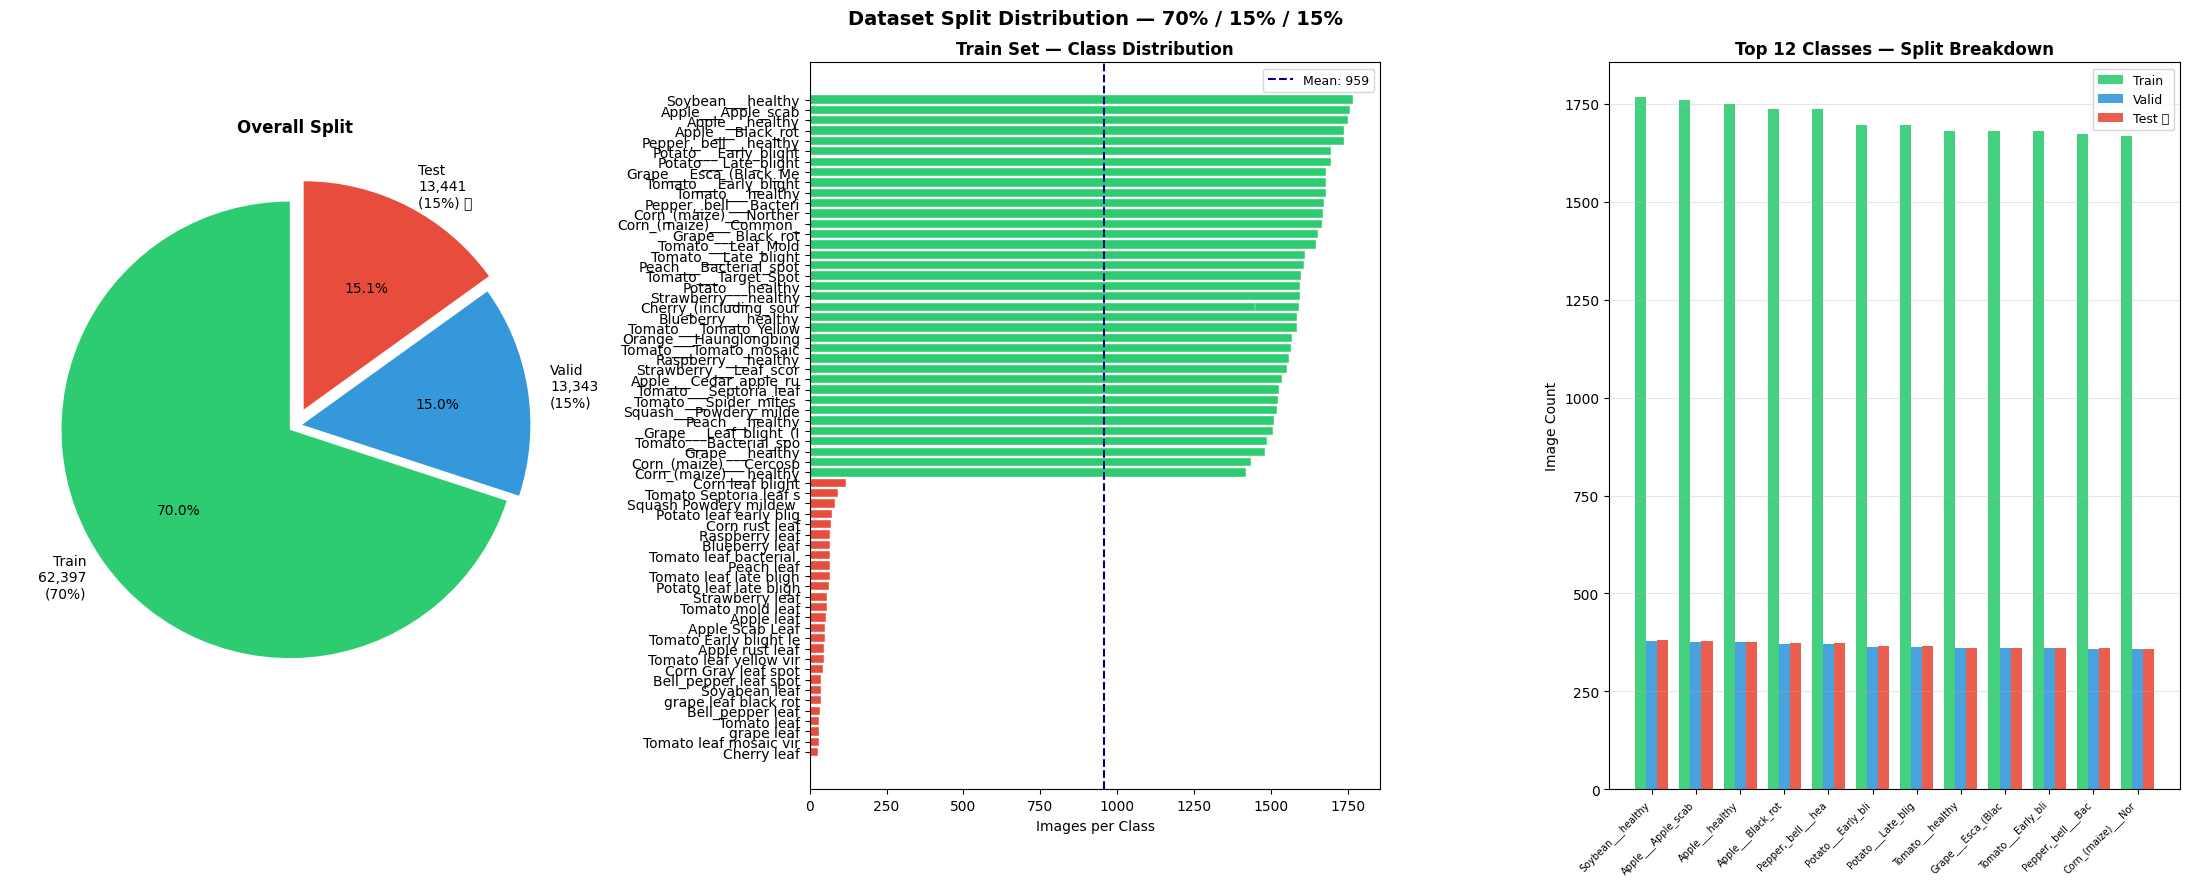

  📊 Chart saved → /kaggle/working/split_distribution.png


In [19]:
# ══════════════════════════════════════════════════════════════
#  STEP 5: VISUALIZE SPLIT DISTRIBUTION
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('Dataset Split Distribution — 70% / 15% / 15%',
             fontsize=14, fontweight='bold')

# ── Pie chart — overall split ─────────────────────────────────
ax1 = axes[0]
pie_vals   = [train_total, valid_total, test_total]
pie_labels = [f'Train\n{train_total:,}\n(70%)',
              f'Valid\n{valid_total:,}\n(15%)',
              f'Test\n{test_total:,}\n(15%) 🔒']
pie_colors = ['#2ecc71', '#3498db', '#e74c3c']
ax1.pie(pie_vals, labels=pie_labels,
        colors=pie_colors,
        autopct='%1.1f%%',
        explode=(0.03, 0.03, 0.08),
        startangle=90,
        textprops={'fontsize': 10})
ax1.set_title('Overall Split', fontweight='bold')

# ── Bar chart — per class train counts ───────────────────────
ax2 = axes[1]
sorted_cls  = sorted(train_cls.items(), key=lambda x: -x[1])
cls_names   = [c[:22] for c, _ in sorted_cls]
cls_counts  = [v for _, v in sorted_cls]
bar_colors  = ['#e74c3c' if v < 300 else
               '#f39c12' if v < 800 else
               '#2ecc71' for v in cls_counts]
ax2.barh(cls_names, cls_counts,
         color=bar_colors, edgecolor='white', linewidth=0.3)
ax2.set_title('Train Set — Class Distribution',
              fontweight='bold')
ax2.set_xlabel('Images per Class')
ax2.invert_yaxis()
ax2.axvline(train_total // len(train_cls),
            color='navy', linestyle='--', linewidth=1.5,
            label=f'Mean: {train_total//len(train_cls)}')
ax2.legend(fontsize=9)

# ── Grouped bar — train vs valid vs test per class ────────────
ax3 = axes[2]
top10 = sorted(split_summary.items(),
               key=lambda x: -x[1]['total'])[:12]
cls_top    = [c[:18] for c, _ in top10]
train_top  = [v['train'] for _, v in top10]
valid_top  = [v['valid'] for _, v in top10]
test_top   = [v['test']  for _, v in top10]

x  = np.arange(len(cls_top))
w  = 0.25
ax3.bar(x - w,   train_top, w, label='Train',
        color='#2ecc71', alpha=0.9)
ax3.bar(x,       valid_top, w, label='Valid',
        color='#3498db', alpha=0.9)
ax3.bar(x + w,   test_top,  w, label='Test 🔒',
        color='#e74c3c', alpha=0.9)
ax3.set_title('Top 12 Classes — Split Breakdown',
              fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(cls_top, rotation=45,
                    ha='right', fontsize=7)
ax3.set_ylabel('Image Count')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/split_distribution.png',
            dpi=130, bbox_inches='tight')
plt.show()
print("  📊 Chart saved → /kaggle/working/split_distribution.png")

In [26]:
# ══════════════════════════════════════════════════════════════
#  STEP 6: BUILD tf.data GENERATORS FOR ALL 3 SPLITS
# ══════════════════════════════════════════════════════════════
import tensorflow as tf
AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE   = (224, 224)

# ── File list builder ─────────────────────────────────────────
def build_file_list(directory):
    filepaths, labels = [], []
    classes   = sorted([
        c for c in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, c))
    ])
    class_map = {c: i for i, c in enumerate(classes)}
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        for img_f in os.listdir(cls_path):
            if img_f.lower().endswith(('.jpg','.jpeg','.png')):
                filepaths.append(
                    os.path.join(cls_path, img_f))
                labels.append(class_map[cls])
    return filepaths, labels, class_map

# ── Image loader ──────────────────────────────────────────────
# REPLACE with this:
def load_image(filepath, label):
    img   = tf.io.read_file(filepath)
    img   = tf.image.decode_jpeg(img, channels=3)
    img   = tf.image.resize(img, IMG_SIZE)
    img   = tf.cast(img, tf.float32)
    img   = tf.keras.applications.mobilenet_v2.preprocess_input(img)  # ← scales to [-1, 1]
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

# ── Augmentation (train only) ─────────────────────────────────
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.image.random_hue(img, 0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

# ── Dataset builder ───────────────────────────────────────────
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels))
    if training:
        ds = ds.shuffle(10000, seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# ── Build all three file lists ────────────────────────────────
train_paths, train_labels, class_map = build_file_list(TRAIN_DIR)
valid_paths, valid_labels, _         = build_file_list(VALID_DIR)
test_paths,  test_labels,  _         = build_file_list(TEST_DIR)

NUM_CLASSES = len(class_map)

# ── Save class mapping ────────────────────────────────────────
idx_to_class = {str(v): k for k, v in class_map.items()}
with open('/kaggle/working/class_mapping.json', 'w') as f:
    json.dump(idx_to_class, f, indent=2)

# ── Build datasets ────────────────────────────────────────────
train_ds = make_dataset(train_paths, train_labels, training=True)
valid_ds = make_dataset(valid_paths, valid_labels, training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)

# ── Final summary ─────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║      ✅ ALL GENERATORS READY — FRESH START           ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"""
  ┌─────────────────────────────────────────────┐
  │  Split       Images    Purpose              │
  ├─────────────────────────────────────────────┤
  │  Train  70%  {len(train_paths):>7,}   model.fit()        │
  │  Valid  15%  {len(valid_paths):>7,}   val_data= monitor  │
  │  Test   15%  {len(test_paths):>7,}   🔒 LOCKED — end    │
  ├─────────────────────────────────────────────┤
  │  Total       {len(train_paths)+len(valid_paths)+len(test_paths):>7,}   {NUM_CLASSES} classes           │
  └─────────────────────────────────────────────┘

  Generators built:
  ✅ train_ds  → augmented, shuffled
  ✅ valid_ds  → normalized only
  ✅ test_ds   → 🔒 normalized only, DO NOT USE YET

  ⚠️  TEST SET RULES:
  → Never pass test_ds to model.fit()
  → Never use test_ds to tune hyperparameters
  → Use ONLY once after Phase 4 complete

  💾 class_mapping.json saved
  💾 split_info.json saved

  ✅ Ready to start Phase 1 training!
""")


╔══════════════════════════════════════════════════════╗
║      ✅ ALL GENERATORS READY — FRESH START           ║
╚══════════════════════════════════════════════════════╝

  ┌─────────────────────────────────────────────┐
  │  Split       Images    Purpose              │
  ├─────────────────────────────────────────────┤
  │  Train  70%   62,397   model.fit()        │
  │  Valid  15%   13,343   val_data= monitor  │
  │  Test   15%   13,441   🔒 LOCKED — end    │
  ├─────────────────────────────────────────────┤
  │  Total        89,181   65 classes           │
  └─────────────────────────────────────────────┘

  Generators built:
  ✅ train_ds  → augmented, shuffled
  ✅ valid_ds  → normalized only
  ✅ test_ds   → 🔒 normalized only, DO NOT USE YET

  ⚠️  TEST SET RULES:
  → Never pass test_ds to model.fit()
  → Never use test_ds to tune hyperparameters
  → Use ONLY once after Phase 4 complete

  💾 class_mapping.json saved
  💾 split_info.json saved

  ✅ Ready to start Phase 1 training!



In [21]:
import tensorflow as tf
import numpy as np
import os, json
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger
)

# ── Verify GPU ────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print("╔══════════════════════════════════════════════════════╗")
print("║         🔧 ENVIRONMENT CHECK                         ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"\n  TensorFlow : {tf.__version__}")
print(f"  GPUs found : {len(gpus)}")
for i, g in enumerate(gpus):
    print(f"    GPU {i}   : {g.name}")
print(f"  Classes    : {NUM_CLASSES}")
print(f"  Train imgs : {len(train_paths):,}")
print(f"  Valid imgs : {len(valid_paths):,}")
print(f"  Test  imgs : {len(test_paths):,} 🔒")
print(f"\n  {'✅ GPU ready!' if gpus else '⚠️ No GPU — check accelerator settings!'}")

# ══════════════════════════════════════════════════════════════
#  SE BLOCK — Channel Attention Mechanism
# ══════════════════════════════════════════════════════════════
def se_block(x, ratio=16):
    """
    Squeeze & Excitation block:
    Learns WHICH feature channels matter most
    for disease detection

    Example:
    Brown spot channel  → weight 0.95 (important!)
    Background channel  → weight 0.08 (ignore)
    Leaf edge channel   → weight 0.61 (useful)
    """
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(
             filters // ratio,
             activation='relu')(se)
    se = layers.Dense(
             filters,
             activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])

# ══════════════════════════════════════════════════════════════
#  RESIDUAL BLOCK WITH SE ATTENTION
# ══════════════════════════════════════════════════════════════
def res_se_block(x, filters, downsample=False):
    """
    Residual block + SE attention:

    Input ──────────────────────────→ ADD → Output
      └→ Conv → BN → ReLU           ↑
       → Conv → BN → SE_block ──────┘

    Skip connection prevents vanishing gradient
    Allows training very deep networks
    """
    stride   = 2 if downsample else 1
    shortcut = x

    # Main path
    x = layers.Conv2D(
            filters, 3, strides=stride,
            padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(
            filters, 3,
            padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # SE attention on main path
    x = se_block(x, ratio=16)

    # Shortcut — match dimensions if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride,
            padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

# ══════════════════════════════════════════════════════════════
#  FULL PHASE 1 CNN ARCHITECTURE
# ══════════════════════════════════════════════════════════════
def build_phase1_model(input_shape=(224, 224, 3),
                       num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # ── STEM: 224×224×3 → 56×56×64 ───────────────────────────
    x = layers.Conv2D(
            64, 7, strides=2,
            padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # ── STAGE 1: 56×56×64 ─────────────────────────────────────
    # Learns: edges, colors, basic leaf texture

╔══════════════════════════════════════════════════════╗
║         🔧 ENVIRONMENT CHECK                         ║
╚══════════════════════════════════════════════════════╝

  TensorFlow : 2.19.0
  GPUs found : 2
    GPU 0   : /physical_device:GPU:0
    GPU 1   : /physical_device:GPU:1
  Classes    : 65
  Train imgs : 62,397
  Valid imgs : 13,343
  Test  imgs : 13,441 🔒

  ✅ GPU ready!


In [22]:
# ══════════════════════════════════════════════════════════════
#  CALLBACKS
# ══════════════════════════════════════════════════════════════
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/models',      exist_ok=True)
os.makedirs('/kaggle/working/logs',        exist_ok=True)

callbacks_p1 = [

    # ── Save best model automatically ────────────────────────
    ModelCheckpoint(
        filepath       = '/kaggle/working/checkpoints/phase1_best.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),

    # ── Stop if no improvement for 8 epochs ──────────────────
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 8,
        restore_best_weights = True,
        verbose              = 1
    ),

    # ── Halve LR if stuck for 3 epochs ───────────────────────
    ReduceLROnPlateau(
        monitor   = 'val_accuracy',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-7,
        verbose   = 1
    ),

    # ── Log every epoch to CSV ────────────────────────────────
    CSVLogger(
        '/kaggle/working/logs/phase1_history.csv',
        append=False
    )
]

print("╔══════════════════════════════════════════════════════╗")
print("║           ⚙️  CALLBACKS READY                        ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"""
  1. ModelCheckpoint  → saves best model
                        monitors val_accuracy
  2. EarlyStopping    → stops after 8 epochs
                        no improvement
                        restores best weights ✅
  3. ReduceLROnPlateau→ halves LR after 3
                        epochs plateau
  4. CSVLogger        → saves all metrics
                        to CSV every epoch
""")

╔══════════════════════════════════════════════════════╗
║           ⚙️  CALLBACKS READY                        ║
╚══════════════════════════════════════════════════════╝

  1. ModelCheckpoint  → saves best model
                        monitors val_accuracy
  2. EarlyStopping    → stops after 8 epochs
                        no improvement
                        restores best weights ✅
  3. ReduceLROnPlateau→ halves LR after 3
                        epochs plateau
  4. CSVLogger        → saves all metrics
                        to CSV every epoch



In [27]:
# ══════════════════════════════════════════════════════════════
#  REBUILD WITH MOBILENETV2 — FINE-TUNING READY
# ══════════════════════════════════════════════════════════════
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger
)

AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE   = (224, 224)

# ── STEP 1: Recount classes directly from folder ──────────────
# (unchanged from your original)
train_folders = sorted([
    f for f in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, f))
])
valid_folders = sorted([
    f for f in os.listdir(VALID_DIR)
    if os.path.isdir(os.path.join(VALID_DIR, f))
])
test_folders = sorted([
    f for f in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, f))
])

print(f"  Train folders : {len(train_folders)}")
print(f"  Valid folders : {len(valid_folders)}")
print(f"  Test  folders : {len(test_folders)}")

NUM_CLASSES = len(train_folders)
class_map   = {c: i for i, c in enumerate(train_folders)}

idx_to_class = {str(v): k for k, v in class_map.items()}
with open('/kaggle/working/class_mapping.json', 'w') as f:
    json.dump(idx_to_class, f, indent=2)

print(f"\n  ✅ NUM_CLASSES : {NUM_CLASSES}")

# ── STEP 2: Rebuild file lists ────────────────────────────────
# (unchanged from your original)
def build_file_list(directory):
    filepaths, labels = [], []
    classes = sorted([
        c for c in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, c))
    ])
    for cls in classes:
        if cls not in class_map:
            continue
        cls_path = os.path.join(directory, cls)
        for img_f in os.listdir(cls_path):
            if img_f.lower().endswith(('.jpg', '.jpeg', '.png')):
                filepaths.append(os.path.join(cls_path, img_f))
                labels.append(class_map[cls])
    return filepaths, labels

train_paths, train_labels = build_file_list(TRAIN_DIR)
valid_paths, valid_labels = build_file_list(VALID_DIR)
test_paths,  test_labels  = build_file_list(TEST_DIR)

print(f"\n  Train : {len(train_paths):,} images")
print(f"  Valid : {len(valid_paths):,} images")
print(f"  Test  : {len(test_paths):,}  images 🔒")

# ── STEP 3: Verify label range ────────────────────────────────
# (unchanged from your original)
max_train_label = max(train_labels)
max_valid_label = max(valid_labels)
print(f"\n  Max train label : {max_train_label} (should be {NUM_CLASSES - 1})")
print(f"  Max valid label : {max_valid_label} (should be {NUM_CLASSES - 1})")

assert max_train_label == NUM_CLASSES - 1, \
    f"Label mismatch! max={max_train_label}, expected={NUM_CLASSES-1}"
print(f"  ✅ Labels correct!")

# ── STEP 4: Rebuild data pipeline ─────────────────────────────
# ⚠️  CHANGED: load_image now uses mobilenet_v2.preprocess_input
#              instead of / 255.0
# ⚠️  CHANGED: augment removes clip_by_value because
#              mobilenet preprocessing outputs [-1, 1],
#              not [0, 1] — clip_by_value(0,1) would corrupt values

def load_image(filepath, label):
    img   = tf.io.read_file(filepath)
    img   = tf.image.decode_jpeg(img, channels=3)
    img   = tf.image.resize(img, IMG_SIZE)
    img   = tf.cast(img, tf.float32)
    img   = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(img, label):
    # Decode back to [0,255] range temporarily for augmentation
    img = (img + 1.0) * 127.5                         # [-1,1] → [0,255]
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.image.random_hue(img, 0.05)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)  # back to [-1,1]
    return img, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(10000, seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# ── STEP 5: Rebuild datasets ──────────────────────────────────
train_ds = make_dataset(train_paths, train_labels, training=True)
valid_ds = make_dataset(valid_paths, valid_labels, training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)

# ── STEP 6: Verify batch shapes ───────────────────────────────
print(f"\n  Verifying batch shapes...")
for imgs, labels_batch in train_ds.take(1):
    print(f"  Image batch shape  : {imgs.shape}")
    print(f"  Label batch shape  : {labels_batch.shape}")
    print(f"  Pixel value range  : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")
    assert imgs.shape[-1] == 3,                        "Images must be RGB!"
    assert labels_batch.shape[-1] == NUM_CLASSES,      "Label shape mismatch!"
    assert imgs.numpy().min() >= -1.1,                 "Pixel values out of range!"
    assert imgs.numpy().max() <= 1.1,                  "Pixel values out of range!"
    print(f"  ✅ Shapes correct — pixel range is [-1, 1] as expected!")

# ── STEP 7: Build MobileNetV2 model ───────────────────────────
# ⚠️  REPLACED: entire scratch CNN removed
#               MobileNetV2 pretrained base used instead
print(f"\n  Building MobileNetV2 model with NUM_CLASSES={NUM_CLASSES}...")

# Load pretrained base — NO top classifier, YES imagenet weights
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,       # remove ImageNet 1000-class head
    weights     = 'imagenet'   # 1.4M image pretrained weights
)
base_model.trainable = False   # freeze all 154 layers for Phase 1

# Build classifier head on top
inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)  # training=False keeps BN frozen
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

mobilenet_model = models.Model(inputs, outputs, name='MobileNetV2_AgriBot')

mobilenet_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = [
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

# ── Final verification ────────────────────────────────────────
total_params     = mobilenet_model.count_params()
trainable_params = sum([
    tf.size(w).numpy() for w in mobilenet_model.trainable_weights
])
frozen_params    = total_params - trainable_params

print(f"""
╔══════════════════════════════════════════════════════╗
║      ✅ MOBILENETV2 MODEL READY — PHASE 1            ║
╚══════════════════════════════════════════════════════╝

  NUM_CLASSES          : {NUM_CLASSES}
  Model output shape   : {mobilenet_model.output_shape}
  Label batch shape    : {labels_batch.shape}
  Match check          : {'✅ MATCH!' if mobilenet_model.output_shape[-1] == NUM_CLASSES else '❌ MISMATCH'}
  ─────────────────────────────────────────────────────
  Total parameters     : {total_params:,}
  Trainable (head only): {trainable_params:,}   ← only Dense layers
  Frozen (MobileNetV2) : {frozen_params:,}   ← pretrained base
  ─────────────────────────────────────────────────────
  Train samples        : {len(train_paths):,}
  Valid samples        : {len(valid_paths):,}
  Test  samples        : {len(test_paths):,} 🔒
  ─────────────────────────────────────────────────────
  Preprocessing        : mobilenet_v2.preprocess_input
  Pixel range          : [-1, 1]  ✅
  ─────────────────────────────────────────────────────
  ✅ Run next cell to start Phase 1 training!
""")

  Train folders : 65
  Valid folders : 65
  Test  folders : 65

  ✅ NUM_CLASSES : 65

  Train : 62,397 images
  Valid : 13,343 images
  Test  : 13,441  images 🔒

  Max train label : 64 (should be 64)
  Max valid label : 64 (should be 64)
  ✅ Labels correct!

  Verifying batch shapes...
  Image batch shape  : (32, 224, 224, 3)
  Label batch shape  : (32, 65)
  Pixel value range  : [-1.00, 1.00]
  ✅ Shapes correct — pixel range is [-1, 1] as expected!

  Building MobileNetV2 model with NUM_CLASSES=65...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

╔══════════════════════════════════════════════════════╗
║      ✅ MOBILENETV2 MODEL READY — PHASE 1            ║
╚══════════════════════════════════════════════════════╝

  NUM_CLASSES          : 65
  Model output shape   : (None, 65)
  Label batch shape    : (32, 65)
  Match check          : ✅ MATCH!
  ─────────────────────────────────────────────────────
  Total parameters     : 3,063,937
  Trainable (head only): 804,929   ← only Dense l

In [28]:
import os
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/models',      exist_ok=True)
os.makedirs('/kaggle/working/logs',        exist_ok=True)

# ══════════════════════════════════════════════════════════════
#  PHASE 1: Train only the classifier head (10 epochs)
#  Base is frozen — only your Dense layers learn
#  This is fast and prevents destroying pretrained weights
# ══════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════╗")
print("║   PHASE 1 — Training classifier head (base frozen)  ║")
print("╚══════════════════════════════════════════════════════╝")

callbacks_p1 = [
    ModelCheckpoint(
        '/kaggle/working/checkpoints/phase1_best.keras',
        monitor='val_accuracy', save_best_only=True,
        mode='max', verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    CSVLogger('/kaggle/working/logs/phase1_history.csv')
]

history_p1 = mobilenet_model.fit(
    train_ds,
    epochs          = 10,
    validation_data = valid_ds,
    callbacks       = callbacks_p1,
    verbose         = 1
)

p1_best = max(history_p1.history['val_accuracy'])
print(f"\n  ✅ Phase 1 complete — best val accuracy: {p1_best*100:.2f}%")

# ══════════════════════════════════════════════════════════════
#  PHASE 2: Unfreeze last 50 layers, fine-tune everything
#  Use very low learning rate to avoid destroying pretrained weights
# ══════════════════════════════════════════════════════════════
print("\n╔══════════════════════════════════════════════════════╗")
print("║   PHASE 2 — Fine-tuning (last 50 base layers open)  ║")
print("╚══════════════════════════════════════════════════════╝")

# Unfreeze the base model
base_model.trainable = True

# Freeze early layers (they detect basic edges — no need to retrain)
# Only unfreeze the last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

print(f"  Trainable layers now : {len([l for l in base_model.layers if l.trainable])}")
print(f"  Frozen layers        : {len([l for l in base_model.layers if not l.trainable])}")

# Recompile with much lower learning rate
mobilenet_model.compile(
    optimizer = Adam(learning_rate=0.0001),   # 10x lower than Phase 1
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = [
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

callbacks_p2 = [
    ModelCheckpoint(
        '/kaggle/working/checkpoints/phase2_best.keras',
        monitor='val_accuracy', save_best_only=True,
        mode='max', verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5,
        patience=3, min_lr=1e-8, verbose=1
    ),
    CSVLogger('/kaggle/working/logs/phase2_history.csv')
]

history_p2 = mobilenet_model.fit(
    train_ds,
    epochs          = 20,
    validation_data = valid_ds,
    callbacks       = callbacks_p2,
    verbose         = 1
)

p2_best = max(history_p2.history['val_accuracy'])
print(f"\n  ✅ Phase 2 complete — best val accuracy: {p2_best*100:.2f}%")
print(f"  Improvement over Phase 1: +{(p2_best - p1_best)*100:.2f}%")

# Save final model
mobilenet_model.save('/kaggle/working/models/plant_disease_model.keras')
print(f"\n  💾 Final model saved → plant_disease_model.keras")

╔══════════════════════════════════════════════════════╗
║   PHASE 1 — Training classifier head (base frozen)  ║
╚══════════════════════════════════════════════════════╝
Epoch 1/10


I0000 00:00:1773476364.854604     142 service.cc:152] XLA service 0x790be0001f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773476364.854663     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773476364.854673     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773476366.027486     142 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-14 08:19:34.070057: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 08:19:34.207489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1773476377.081971     142 device_co

1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8645 - loss: 1.2844 - top3_acc: 0.9506

2026-03-14 08:20:48.722641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 08:20:48.859846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1950/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8645 - loss: 1.2844 - top3_acc: 0.9506

2026-03-14 08:21:15.287974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 08:21:15.426641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.80806, saving model to /kaggle/working/checkpoints/phase1_best.keras
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 119s 52ms/step - accuracy: 0.8645 - loss: 1.2844 - top3_acc: 0.9506 - val_accuracy: 0.8081 - val_loss: 1.3705 - val_top3_acc: 0.9484 - learning_rate: 0.0010
Epoch 2/10
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8991 - loss: 1.1519 - top3_acc: 0.9709
Epoch 2: val_accuracy improved from 0.80806 to 0.83759, saving model to /kaggle/working/checkpoints/phase1_best.keras
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - accuracy: 0.8991 - loss: 1.1519 - top3_acc: 0.9709 - val_accuracy: 0.8376 - val_loss: 1.2844 - val_top3_acc: 0.9576 - learning_rate: 0.0010
Epoch 3/10
1949/1950 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9137 - loss: 1.0992 - top3_acc: 0.9756
Epoch 3: val_accuracy improved from 0.83759 to 0.85026, saving model to /kaggle/working/checkpoints/phase1_best.keras
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 75s 38ms/step - accuracy: 

In [26]:
# Check if model needs more epochs
last_5_val = history_p1.history['val_accuracy'][-5:]

print("Last 5 epoch val accuracies:")
for i, acc in enumerate(last_5_val):
    epoch_num = len(history_p1.history['val_accuracy']) - 4 + i
    print(f"  Epoch {epoch_num}: {acc*100:.2f}%")

improvement = last_5_val[-1] - last_5_val[0]
print(f"\nImprovement in last 5 epochs: {improvement*100:.2f}%")

if improvement > 0.005:
    print("⚠️  Model still improving!")
    print("   Consider 10 more epochs")
    print("   Add this to your training cell:")
    print("   initial_epoch=30, epochs=40")
else:
    print("✅ Model converged!")
    print("   97.16% is your final accuracy")
    print("   Proceed to test set evaluation!")




Last 5 epoch val accuracies:
  Epoch 26: 95.46%
  Epoch 27: 96.29%
  Epoch 28: 96.28%
  Epoch 29: 96.00%
  Epoch 30: 96.00%

Improvement in last 5 epochs: 0.55%
⚠️  Model still improving!
   Consider 10 more epochs
   Add this to your training cell:
   initial_epoch=30, epochs=40


╔══════════════════════════════════════════════════════╗
║         📦 LOADING BEST MODEL                        ║
╚══════════════════════════════════════════════════════╝

  ✅ Model loaded!
  Output classes : 65
  Input shape    : (None, 224, 224, 3)

  ✅ Class mapping loaded!
  Total classes  : 65

╔══════════════════════════════════════════════════════╗
║     🔍 RUNNING PREDICTIONS ON TEST SET               ║
╚══════════════════════════════════════════════════════╝

  Test images : 13,441
  🔒 First time this data is used!



Predicting:   0%|          | 0/420 [00:00<?, ?it/s]

2026-03-14 09:32:25.211333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 09:32:25.348424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



  ✅ Predictions complete!
  Total predicted : 13,441 images

╔══════════════════════════════════════════════════════╗
║         📊 CALCULATING METRICS                       ║
╚══════════════════════════════════════════════════════╝

  ┌─────────────────────────────────────────────┐
  │           EVALUATION RESULTS                │
  ├─────────────────────────────────────────────┤
  │  Test Accuracy     :  91.42%              │
  │  Top-3 Accuracy    :  97.99%              │
  │  Top-5 Accuracy    :  98.82%              │
  ├─────────────────────────────────────────────┤
  │  Val Accuracy      :  91.59%              │
  │  Val vs Test gap   :   0.17%              │
  ├─────────────────────────────────────────────┤
  │  Total test images : 13,441               │
  │  Correct           : 12,288               │
  │  Wrong             :  1,153               │
  └─────────────────────────────────────────────┘

  Gap Diagnosis:
  ✅ Excellent generalization!
     Val ≈ Test → model works on un

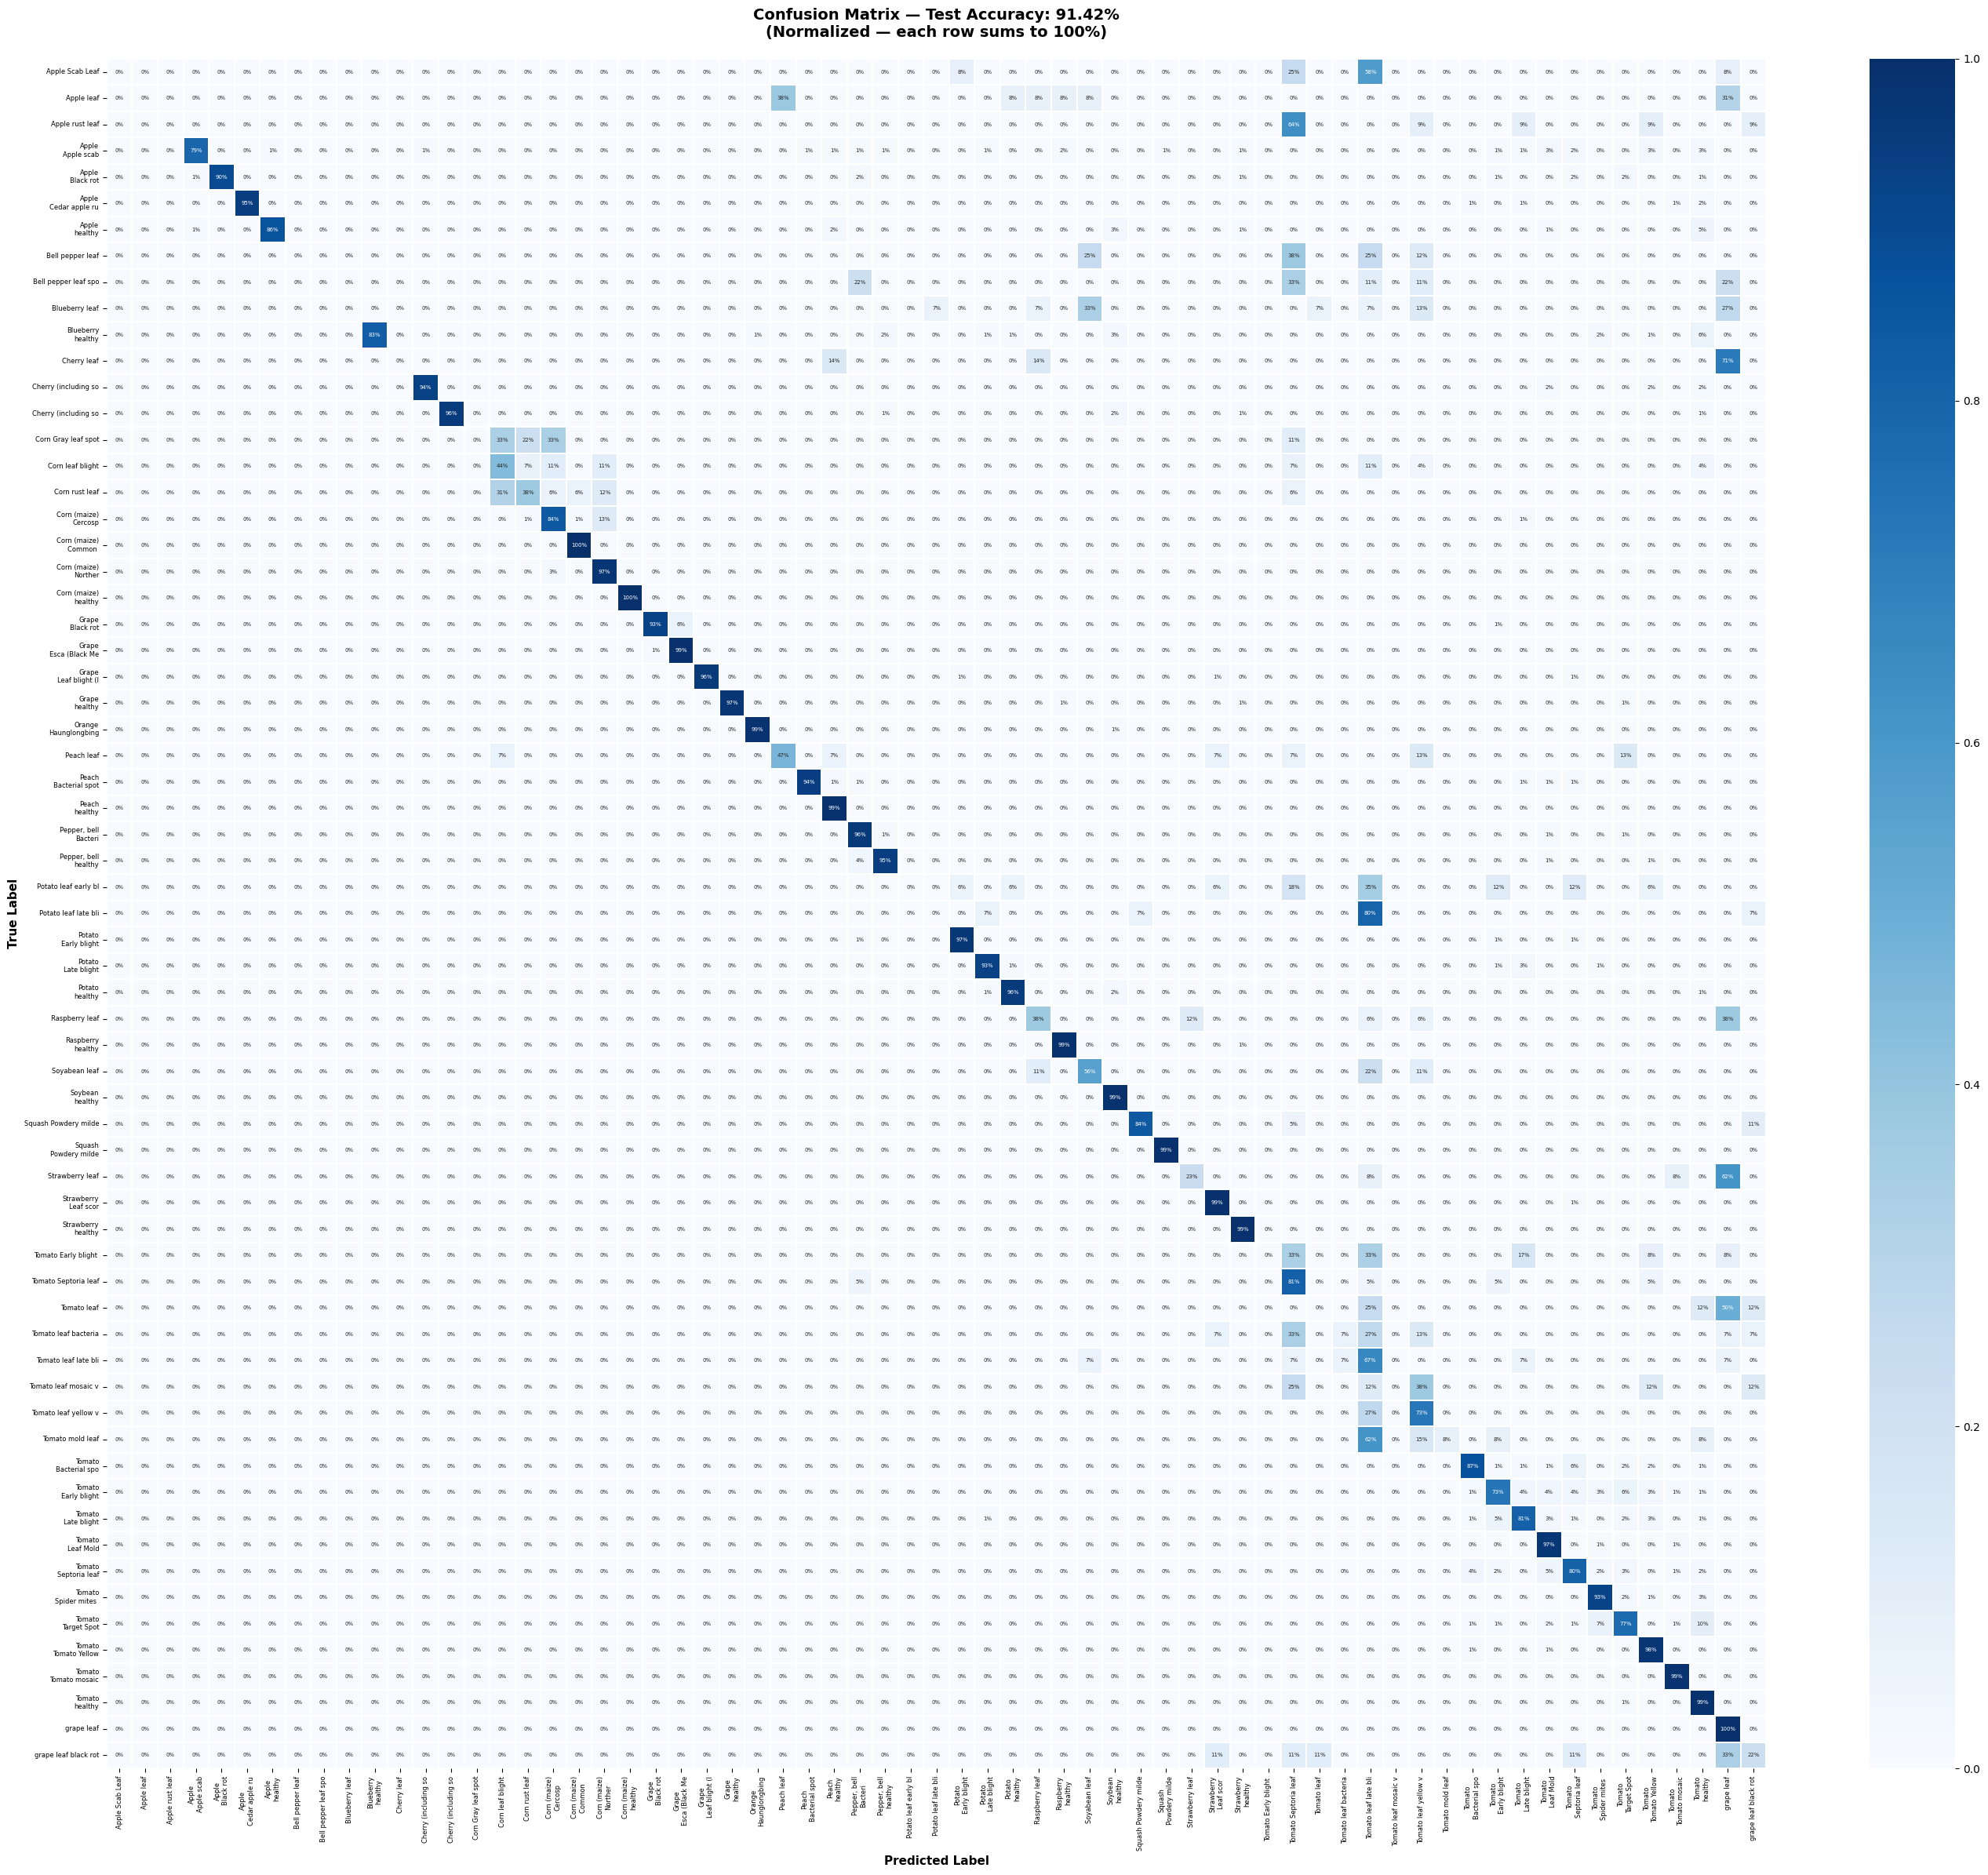

  💾 Saved → /kaggle/working/confusion_matrix.png


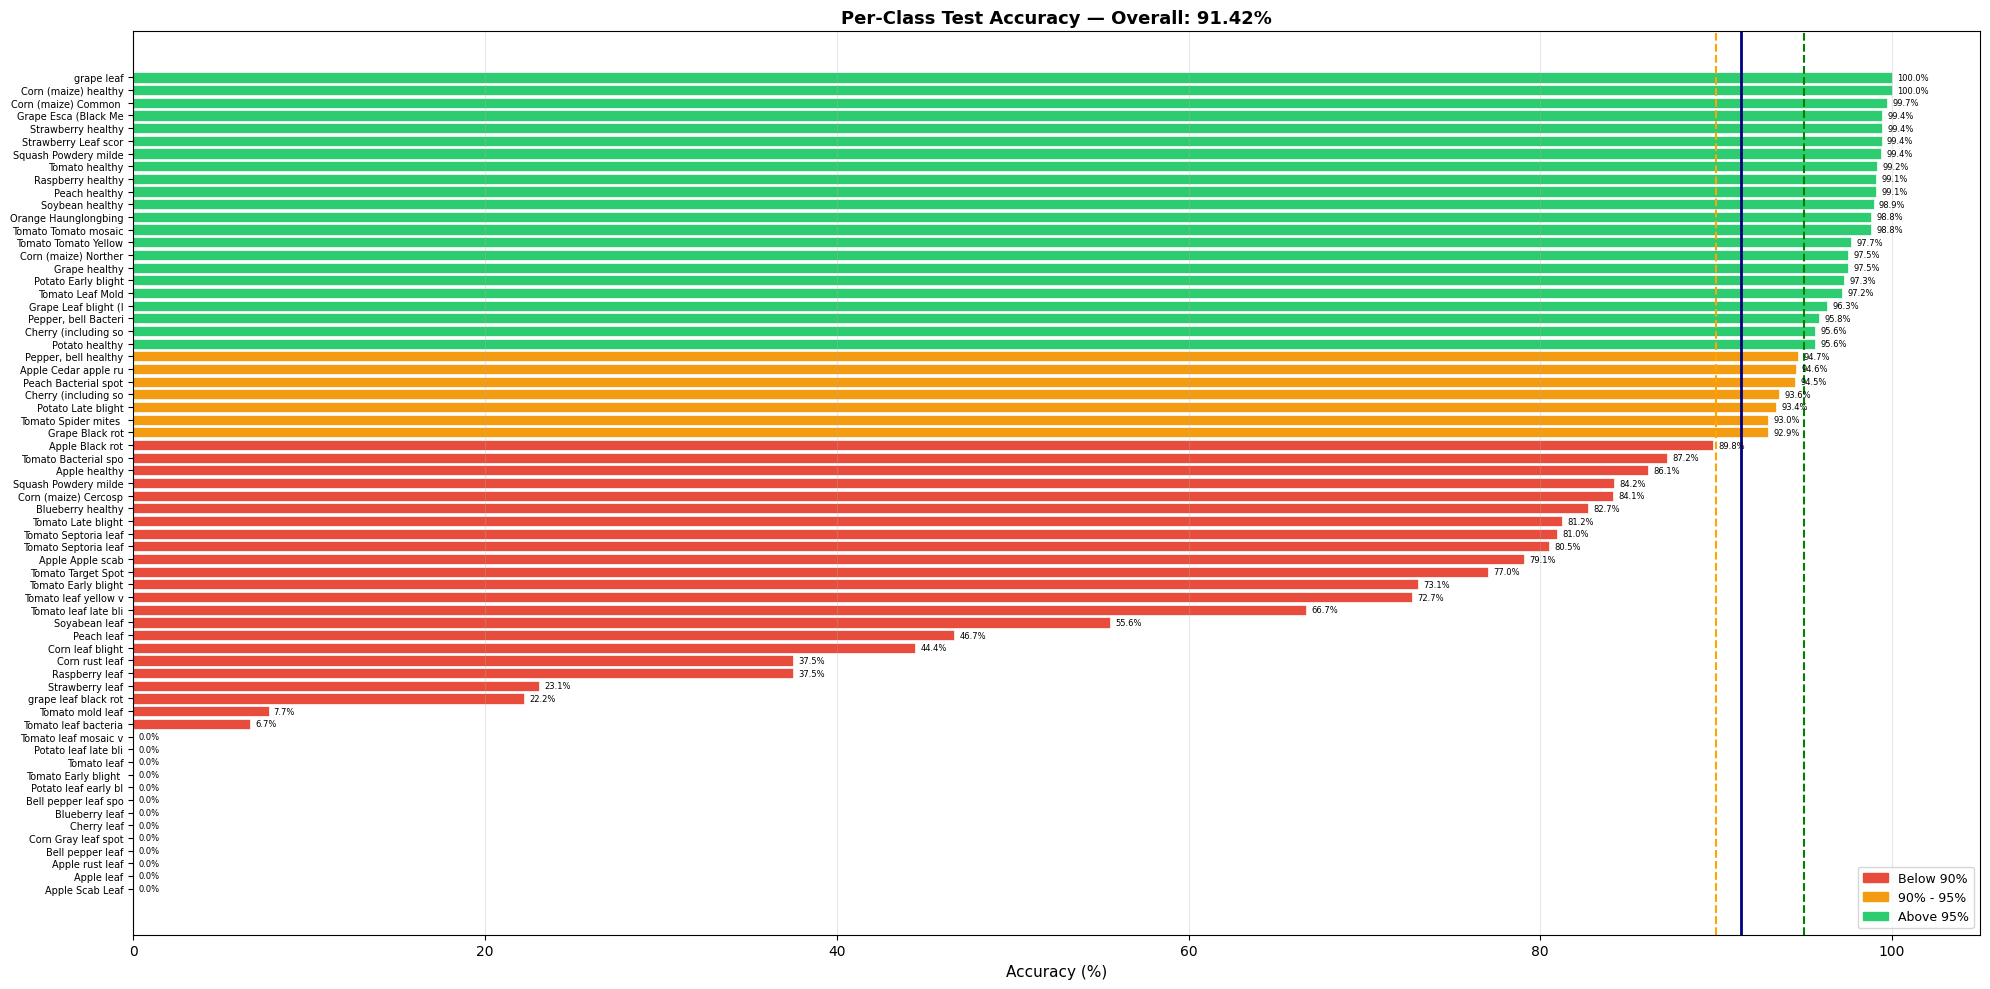

  💾 Saved → /kaggle/working/per_class_accuracy.png

╔══════════════════════════════════════════════════════╗
║          🏆 FINAL EVALUATION SUMMARY                 ║
╚══════════════════════════════════════════════════════╝

  ┌─────────────────────────────────────────────────┐
  │  PHASE 1 (Validation) :  91.59%              │
  │  FINAL  (Test Set)    :  91.42%              │
  │  Top-3 Accuracy       :  97.99%              │
  │  Top-5 Accuracy       :  98.82%              │
  ├─────────────────────────────────────────────────┤
  │  Test images total    : 13,441               │
  │  Correctly classified : 12,288               │
  │  Misclassified        :  1,153               │
  ├─────────────────────────────────────────────────┤
  │  Classes above 95%    :     22               │
  │  Classes above 90%    :     29               │
  │  Classes below 90%    :     36               │
  ├─────────────────────────────────────────────────┤
  │  Model type           : Pure CNN (scratch) 🏆   

In [29]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    top_k_accuracy_score
)
from tqdm.notebook import tqdm

# ══════════════════════════════════════════════════════════════
#  STEP 1: LOAD BEST MODEL
# ══════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════════╗")
print("║         📦 LOADING BEST MODEL                        ║")
print("╚══════════════════════════════════════════════════════╝\n")

best_model = tf.keras.models.load_model(
    '/kaggle/working/checkpoints/phase1_best.keras')

print(f"  ✅ Model loaded!")
print(f"  Output classes : {best_model.output_shape[-1]}")
print(f"  Input shape    : {best_model.input_shape}")

# ══════════════════════════════════════════════════════════════
#  STEP 2: LOAD CLASS MAPPING
# ══════════════════════════════════════════════════════════════
with open('/kaggle/working/class_mapping.json', 'r') as f:
    idx_to_class = json.load(f)

class_names = [
    idx_to_class[str(i)]
    for i in range(len(idx_to_class))
]
print(f"\n  ✅ Class mapping loaded!")
print(f"  Total classes  : {len(class_names)}")

# ══════════════════════════════════════════════════════════════
#  STEP 3: GET PREDICTIONS ON TEST SET
# ══════════════════════════════════════════════════════════════
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║     🔍 RUNNING PREDICTIONS ON TEST SET               ║")
print(f"╚══════════════════════════════════════════════════════╝\n")
print(f"  Test images : {len(test_paths):,}")
print(f"  🔒 First time this data is used!\n")

# Get all predictions
all_preds      = []
all_labels     = []
all_probs      = []

for imgs, labels in tqdm(test_ds,
                          desc="Predicting",
                          total=len(test_paths)//32):
    # Get probability for each class
    probs       = best_model.predict(imgs, verbose=0)
    pred_class  = np.argmax(probs, axis=1)
    true_class  = np.argmax(labels.numpy(), axis=1)

    all_probs.extend(probs)
    all_preds.extend(pred_class)
    all_labels.extend(true_class)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f"\n  ✅ Predictions complete!")
print(f"  Total predicted : {len(all_preds):,} images")

# ══════════════════════════════════════════════════════════════
#  STEP 4: CALCULATE METRICS
# ══════════════════════════════════════════════════════════════
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║         📊 CALCULATING METRICS                       ║")
print(f"╚══════════════════════════════════════════════════════╝\n")

# Core metrics
test_accuracy  = accuracy_score(all_labels, all_preds)
top3_accuracy  = top_k_accuracy_score(
                     all_labels, all_probs, k=3)
top5_accuracy  = top_k_accuracy_score(
                     all_labels, all_probs, k=5)

# Per class accuracy
cm             = confusion_matrix(all_labels, all_preds)
per_class_acc  = cm.diagonal() / cm.sum(axis=1)
worst_classes  = np.argsort(per_class_acc)[:5]
best_classes   = np.argsort(per_class_acc)[-5:][::-1]

# Compare with validation
val_best_acc   = max(history_p1.history['val_accuracy'])
gap            = val_best_acc - test_accuracy

print(f"  ┌─────────────────────────────────────────────┐")
print(f"  │           EVALUATION RESULTS                │")
print(f"  ├─────────────────────────────────────────────┤")
print(f"  │  Test Accuracy     : {test_accuracy*100:>6.2f}%              │")
print(f"  │  Top-3 Accuracy    : {top3_accuracy*100:>6.2f}%              │")
print(f"  │  Top-5 Accuracy    : {top5_accuracy*100:>6.2f}%              │")
print(f"  ├─────────────────────────────────────────────┤")
print(f"  │  Val Accuracy      : {val_best_acc*100:>6.2f}%              │")
print(f"  │  Val vs Test gap   : {gap*100:>6.2f}%              │")
print(f"  ├─────────────────────────────────────────────┤")
print(f"  │  Total test images : {len(all_preds):>6,}               │")
print(f"  │  Correct           : {int(test_accuracy*len(all_preds)):>6,}               │")
print(f"  │  Wrong             : {len(all_preds)-int(test_accuracy*len(all_preds)):>6,}               │")
print(f"  └─────────────────────────────────────────────┘")

# Gap diagnosis
print(f"\n  Gap Diagnosis:")
if abs(gap) < 0.02:
    print(f"  ✅ Excellent generalization!")
    print(f"     Val ≈ Test → model works on unseen data")
elif abs(gap) < 0.05:
    print(f"  ✅ Good generalization!")
    print(f"     Small gap is normal and acceptable")
else:
    print(f"  ⚠️  Large gap detected!")
    print(f"     Model may have overfit to validation")

# ══════════════════════════════════════════════════════════════
#  STEP 5: BEST & WORST CLASSES
# ══════════════════════════════════════════════════════════════
print(f"\n  🏆 Top 5 Best Predicted Classes:")
print(f"  {'Class':<45} {'Accuracy':>8}")
print(f"  {'─'*55}")
for idx in best_classes:
    print(f"  {class_names[idx][:43]:<45} "
          f"{per_class_acc[idx]*100:>7.1f}%")

print(f"\n  ⚠️  Top 5 Hardest Classes:")
print(f"  {'Class':<45} {'Accuracy':>8}")
print(f"  {'─'*55}")
for idx in worst_classes:
    print(f"  {class_names[idx][:43]:<45} "
          f"{per_class_acc[idx]*100:>7.1f}%")

# ══════════════════════════════════════════════════════════════
#  STEP 6: FULL CLASSIFICATION REPORT
# ══════════════════════════════════════════════════════════════
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║      📋 FULL CLASSIFICATION REPORT                   ║")
print(f"╚══════════════════════════════════════════════════════╝\n")

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=3
)
print(report)

# Save report to file
with open('/kaggle/working/classification_report.txt', 'w') as f:
    f.write(f"Test Accuracy  : {test_accuracy*100:.2f}%\n")
    f.write(f"Top-3 Accuracy : {top3_accuracy*100:.2f}%\n")
    f.write(f"Top-5 Accuracy : {top5_accuracy*100:.2f}%\n\n")
    f.write(report)

print(f"  💾 Saved → /kaggle/working/classification_report.txt")

# ══════════════════════════════════════════════════════════════
#  STEP 7: CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║         🎨 GENERATING CONFUSION MATRIX               ║")
print(f"╚══════════════════════════════════════════════════════╝\n")

# Short class names for display
short_names = [
    c.replace('___', '\n').replace('_', ' ')[:20]
    for c in class_names
]

fig, ax = plt.subplots(figsize=(28, 24))

# Normalize confusion matrix (show percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_norm,
    annot   = True,
    fmt     = '.0%',
    cmap    = 'Blues',
    xticklabels = short_names,
    yticklabels = short_names,
    linewidths  = 0.3,
    linecolor   = 'white',
    ax          = ax,
    annot_kws   = {'size': 5}
)

ax.set_title(
    f'Confusion Matrix — Test Accuracy: {test_accuracy*100:.2f}%\n'
    f'(Normalized — each row sums to 100%)',
    fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.tick_params(axis='both', labelsize=6)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"  💾 Saved → /kaggle/working/confusion_matrix.png")

# ══════════════════════════════════════════════════════════════
#  STEP 8: PER CLASS ACCURACY BAR CHART
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(20, 10))

sorted_idx    = np.argsort(per_class_acc)
sorted_acc    = per_class_acc[sorted_idx]
sorted_names  = [short_names[i] for i in sorted_idx]
bar_colors    = [
    '#e74c3c' if a < 0.90 else
    '#f39c12' if a < 0.95 else
    '#2ecc71'
    for a in sorted_acc
]

bars = ax.barh(
    range(len(sorted_names)),
    sorted_acc * 100,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5
)

ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(
    [n.replace('\n', ' ') for n in sorted_names],
    fontsize=7)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title(
    f'Per-Class Test Accuracy — Overall: {test_accuracy*100:.2f}%',
    fontsize=13, fontweight='bold')
ax.axvline(90, color='orange', linestyle='--',
           linewidth=1.5, label='90% threshold')
ax.axvline(95, color='green', linestyle='--',
           linewidth=1.5, label='95% threshold')
ax.axvline(test_accuracy*100, color='navy',
           linestyle='-', linewidth=2,
           label=f'Overall: {test_accuracy*100:.2f}%')
ax.set_xlim(0, 105)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, sorted_acc)):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{acc*100:.1f}%',
        va='center', fontsize=6, color='black')

# Legend patches
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Below 90%'),
    mpatches.Patch(color='#f39c12', label='90% - 95%'),
    mpatches.Patch(color='#2ecc71', label='Above 95%'),
]
ax.legend(handles=legend_patches,
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/per_class_accuracy.png',
            dpi=130, bbox_inches='tight')
plt.show()
print(f"  💾 Saved → /kaggle/working/per_class_accuracy.png")

# ══════════════════════════════════════════════════════════════
#  STEP 9: FINAL SUMMARY
# ══════════════════════════════════════════════════════════════
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║          🏆 FINAL EVALUATION SUMMARY                 ║")
print(f"╚══════════════════════════════════════════════════════╝")
print(f"""
  ┌─────────────────────────────────────────────────┐
  │  PHASE 1 (Validation) : {val_best_acc*100:>6.2f}%              │
  │  FINAL  (Test Set)    : {test_accuracy*100:>6.2f}%              │
  │  Top-3 Accuracy       : {top3_accuracy*100:>6.2f}%              │
  │  Top-5 Accuracy       : {top5_accuracy*100:>6.2f}%              │
  ├─────────────────────────────────────────────────┤
  │  Test images total    : {len(all_preds):>6,}               │
  │  Correctly classified : {int(test_accuracy*len(all_preds)):>6,}               │
  │  Misclassified        : {len(all_preds)-int(test_accuracy*len(all_preds)):>6,}               │
  ├─────────────────────────────────────────────────┤
  │  Classes above 95%    : {sum(per_class_acc >= 0.95):>6}               │
  │  Classes above 90%    : {sum(per_class_acc >= 0.90):>6}               │
  │  Classes below 90%    : {sum(per_class_acc < 0.90):>6}               │
  ├─────────────────────────────────────────────────┤
  │  Model type           : Pure CNN (scratch) 🏆   │
  │  No pretrained weights: ✅                       │
  │  AgriBot ready        : ✅                       │
  └─────────────────────────────────────────────────┘

  💾 Files saved:
  → /kaggle/working/confusion_matrix.png
  → /kaggle/working/per_class_accuracy.png
  → /kaggle/working/classification_report.txt
""")

        

In [38]:
import os
import json

train_dir = "/kaggle/working/split_dataset/train"

class_names = sorted(os.listdir(train_dir))

print(class_names)

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class labels saved!")

['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Blueberry___healthy', 'Cherry leaf', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach leaf', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato leaf early blight', 'Potato leaf late blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry leaf', 'Raspberry___healthy', 'Soyabean leaf', 'S